#### **Imports**

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import readsav
from pathlib import Path
from scipy.fft import fft, ifft
import kneed
import maos_utils as mu
from astropy.io import fits

#### **Load LGS telemetry files**
##### and pull/calculate necessary information, rather than storing entire ``data`` object

``STRAPDQMN`` : one number for entire night of observation/telemetry. Provided in FITS image header and telemetry data.header. Units in KAON are "quad mean apd counts"
* compare to *input* ``powfs.siglev`` for ``STRAP``

``LGRMSWF``   : one number for entire night of observation/telemetry. Provided in FITS image header and telemetry data.header. Units are nm
* compare to *output* ``MAOS HO WFE``

``STINTTIM`` : ``STRAP`` integration times, one setting for entire night of observation. Provided in FITS image header and telemetry data.header. Units are ms
* compare to ``data.b.timestamps[0]`` interval/spacing

``WSFRRT``    : ``SHWFS`` frame rate, one setting for entire night of observation. Provided in FITS image header and telemetry data.header. Units are in Hz
* compare to ``data.a.timestamps[0]`` interval/spacing after converting to milli-seconds (like ``STRAP``)

``APDCOUNTS`` : [4, # of timestamps] array for night of observation. 4 refers to 4 WFS quadrants. Units are in counts.
* Average over all 4 quadrants over night to get one number per night/telemetry file --> compare this to ``STRAPDQMN`` using gain settings
* ``APD_SKY_BACK`` is [1, 4] array for night of observation. 4 refers to 4 WFS quadrants. Units are **unclear**. Based on shape of data array, I think this is the background for each WFS quadrant for the entire night (one quantity per quadrant per telemetry file)
* compare calculated ``APDCOUNTS`` using expected relationship with ``STRAPDQMN`` (telemetry ``data`` header quantity) versus ``APDCOUNTS`` from telemetry ``data``

``SUBAPINTENSITY`` : [304, # of timestamps] array for night of observation. 304 refers to 304 sub-apertures. Units are in adu.
* compare to *input* ``powfs.siglev`` for ``SHWFS``

``RESIDUALRMS`` : [# of timestamps] array for night of observation. Units are in nm.
* Average over entire timestream for one quantity per night/telemetry file



In [ ]:
telemetry = mu.telemetry_data()

In [114]:
# Read in telemetry CSV that already exists for all dates (06/24/2024)
import pandas as pd
columns = (['filename', 'LGRMSWFs', 'STRAPDQMNs', 'SUBAPINTs', 
            'STINTTIMs', 'DATA.B Time Interval',
            'SHWFS int times', 'DATA.A Time Interval',
            'APDCOUNTS', 'APD_SKY_BACK', 
            'RESIDUALRMS', 'RMSWFE', 
            'DMGAIN', 'DTGAIN', 'UTGAIN',
            'STRAP SIGLEV', 'STRAP BKGRND', 
            'SHWFS SIGLEV', 'SHWFS BKGRND', 'SHWFS GAIN'])
telemetry = pd.read_csv("/Users/bdigia/work/ao/keck/maos/keck/my_base/LGS_telemetry.csv", 
                        names=columns, header=0)

#### **Display ``telemetry`` dataframe**

>> ``telemetry.style`` for no row truncation and nice styling, though large output

#### **Validate telemetry rate with SHWFS / STRAP integration times from FITS header & ``data.header``**

In [116]:
plt.rcParams.update({
    "text.usetex": False, # turn off latex rendering
    "font.sans-serif": "Helvetica",
})

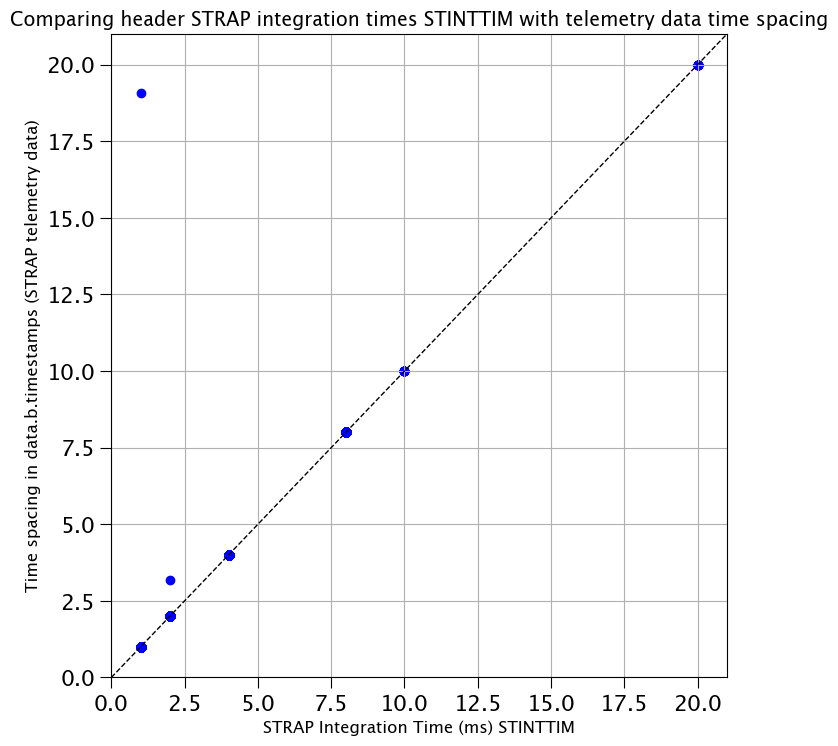

In [47]:
stinttims = telemetry['STINTTIMs'].astype(float)
data_b_intervals = telemetry['DATA.B Time Interval'].astype(float)

fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(stinttims, data_b_intervals, color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.ylim(0.0, 21.0)
plt.xlim(0.0, 21.0)
plt.xlabel("STRAP Integration Time (ms) STINTTIM", fontsize=12)
plt.ylabel("Time spacing in data.b.timestamps (STRAP telemetry data)", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.title("Comparing header STRAP integration times STINTTIM with telemetry data time spacing", fontsize=14)
plt.show()

In [50]:
telemetry[telemetry['STINTTIMs'].astype(float) != round(telemetry['DATA.B Time Interval'].astype(float), 1)]

,filename,LGRMSWFs,STRAPDQMNs,SUBAPINTs,STINTTIMs,DATA.B Time Interval,SHWFS int times,DATA.A Time Interval,APDCOUNTS,APD_SKY_BACK,RESIDUALRMS,RMSWFE,DMGAIN,DTGAIN,UTGAIN,STRAP SIGLEV,STRAP BKGRND,SHWFS SIGLEV,SHWFS BKGRND,SHWFS GAIN
315,/g/lu/data/keck_telemetry/20170505/sdata901/ni...,300.0,23172.75,41.686687,2.0,3.180027,1.333333,1.333559,106.172691,18.856001,5142.502930,2386.451904,0.4,0.20,0.10,1530.125855,7.809331,800.475877,0.094971,4.0
1305,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,300.0,0.00,6527.693359,1.0,19.082781,1.000000,1.000354,0.554424,0.000000,1.635171,716.926819,0.1,0.05,0.05,765.062927,3.904666,600.356908,0.071228,4.0


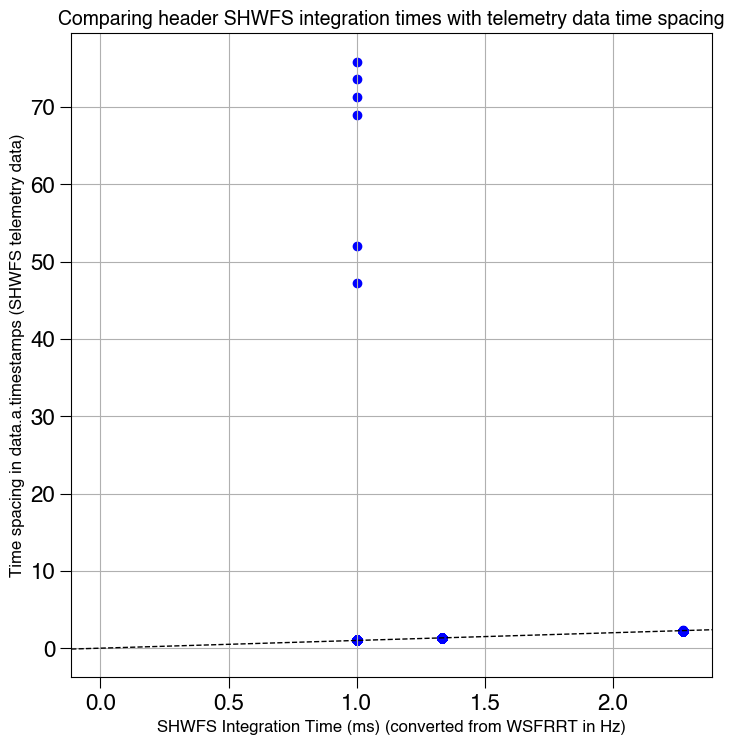

In [51]:
shwfs_times = telemetry['SHWFS int times'].astype(float)
data_a_intervals = telemetry['DATA.A Time Interval'].astype(float)

fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(shwfs_times, data_a_intervals, color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.xlabel("SHWFS Integration Time (ms) (converted from WSFRRT in Hz)", fontsize=12)
plt.ylabel("Time spacing in data.a.timestamps (SHWFS telemetry data)", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.title("Comparing header SHWFS integration times with telemetry data time spacing", fontsize=14)
plt.show()

In [52]:
telemetry[round(telemetry['SHWFS int times'].astype(float), 1) != round(telemetry['DATA.A Time Interval'].astype(float), 1)]

,filename,LGRMSWFs,STRAPDQMNs,SUBAPINTs,STINTTIMs,DATA.B Time Interval,SHWFS int times,DATA.A Time Interval,APDCOUNTS,APD_SKY_BACK,RESIDUALRMS,RMSWFE,DMGAIN,DTGAIN,UTGAIN,STRAP SIGLEV,STRAP BKGRND,SHWFS SIGLEV,SHWFS BKGRND,SHWFS GAIN
1466,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,712.9,705783.75,247.650452,1.0,1.000048,1.0,75.796642,0.598217,0.0,1546.150879,1550.400024,0.4,0.1,0.1,765.062927,3.904666,600.356908,0.071228,4.0
1467,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,817.5,673432.75,240.585510,1.0,1.000048,1.0,73.602165,0.598217,0.0,1552.096680,1545.537231,0.4,0.1,0.1,765.062927,3.904666,600.356908,0.071228,4.0
1468,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,852.3,648249.50,233.103439,1.0,1.000048,1.0,71.261103,0.598217,0.0,1558.043701,1540.130859,0.4,0.1,0.1,765.062927,3.904666,600.356908,0.071228,4.0
1469,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,886.8,616052.50,226.400864,1.0,1.000048,1.0,68.919699,0.598217,0.0,1563.143555,1534.877319,0.4,0.1,0.1,765.062927,3.904666,600.356908,0.071228,4.0
1470,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,267.0,177767.00,175.715866,1.0,1.000048,1.0,52.092753,0.598217,0.0,1566.036743,1458.989380,0.4,0.1,0.1,765.062927,3.904666,600.356908,0.071228,4.0
1471,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,569.7,149003.25,162.540848,1.0,1.000048,1.0,47.263652,0.598217,0.0,1532.600220,1430.140869,0.4,0.1,0.1,765.062927,3.904666,600.356908,0.071228,4.0


In [117]:
cleaned_telem = telemetry[(telemetry['STINTTIMs'].astype(float) == round(telemetry['DATA.B Time Interval'].astype(float), 1)) & (round(telemetry['SHWFS int times'].astype(float), 1) == round(telemetry['DATA.A Time Interval'].astype(float), 1))]

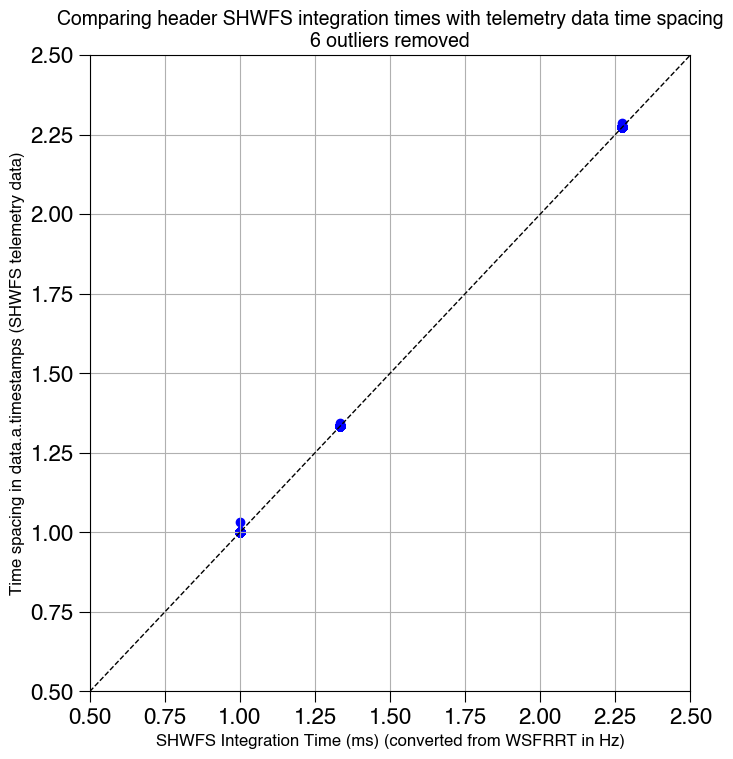

In [54]:
shwfs_times = cleaned_telem['SHWFS int times'].astype(float)
data_a_intervals = cleaned_telem['DATA.A Time Interval'].astype(float)
outliers = telemetry[round(telemetry['SHWFS int times'].astype(float), 1) != round(telemetry['DATA.A Time Interval'].astype(float), 1)].shape[0]

fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(shwfs_times, data_a_intervals, color="blue")
# y=x line (desired correlation)
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.ylim(0.5, 2.5)
plt.xlim(0.5, 2.5)
plt.xlabel("SHWFS Integration Time (ms) (converted from WSFRRT in Hz)", fontsize=12)
plt.ylabel("Time spacing in data.a.timestamps (SHWFS telemetry data)", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.title(f"Comparing header SHWFS integration times with telemetry data time spacing\n{outliers} outliers removed", fontsize=14)
plt.show()

#### **Compare LGRMSWF, RESIDUALRMS, and RMSWFE**
``LGRMSWF`` is value from FITS image and ``data`` ``header``s - closed-loop HO wavefront residual [nm]

``RESIDUALRMS`` (see above)

``RMSWFE`` calculated from ``residualwavefront`` telemetry data in ``centroid_residual_to_RMSWFE(...)``
* ** *TO DO* ** : add ``MAOS HO WFE`` (computed from MAOS)

##### Scatter plot

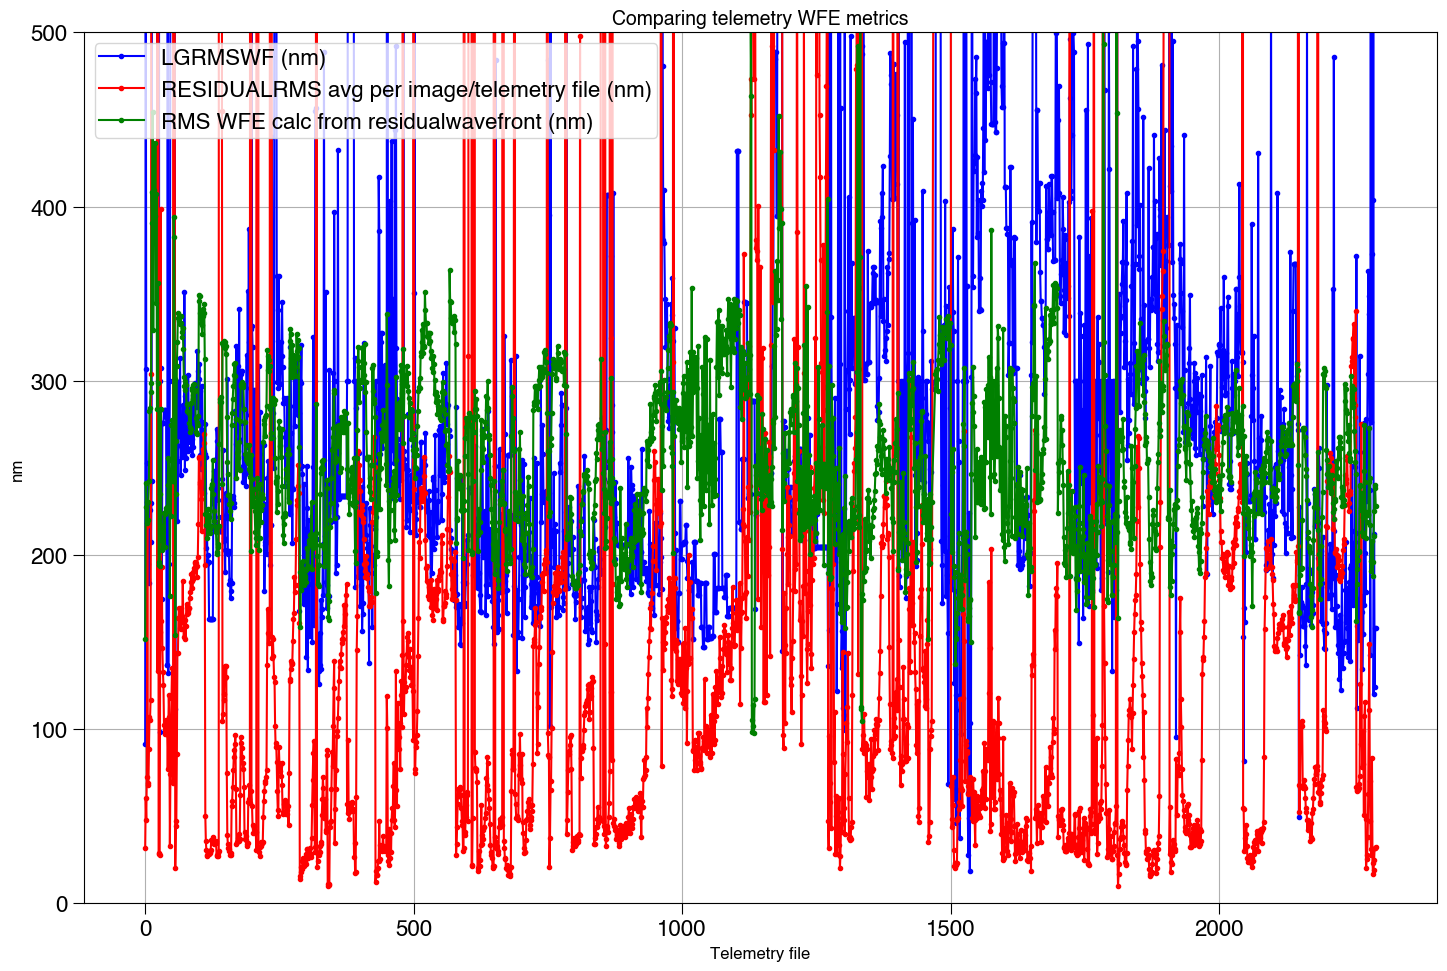

In [55]:
fig, axes = plt.subplots(figsize=(15, 10))
plt.plot(cleaned_telem['LGRMSWFs'].astype(float), '.-', color="blue", label="LGRMSWF (nm)")
plt.plot(cleaned_telem['RESIDUALRMS'].astype(float), '.-', color="red", label="RESIDUALRMS avg per image/telemetry file (nm)")
plt.plot(cleaned_telem['RMSWFE'].astype(float)/10.0, '.-', color="green", label="RMS WFE calc from residualwavefront (nm)")
plt.title("Comparing telemetry WFE metrics", fontsize=14)
plt.xlabel("Telemetry file", fontsize=12)
plt.ylabel("nm", fontsize=12)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.ylim(0.0, 500.0)
plt.show()

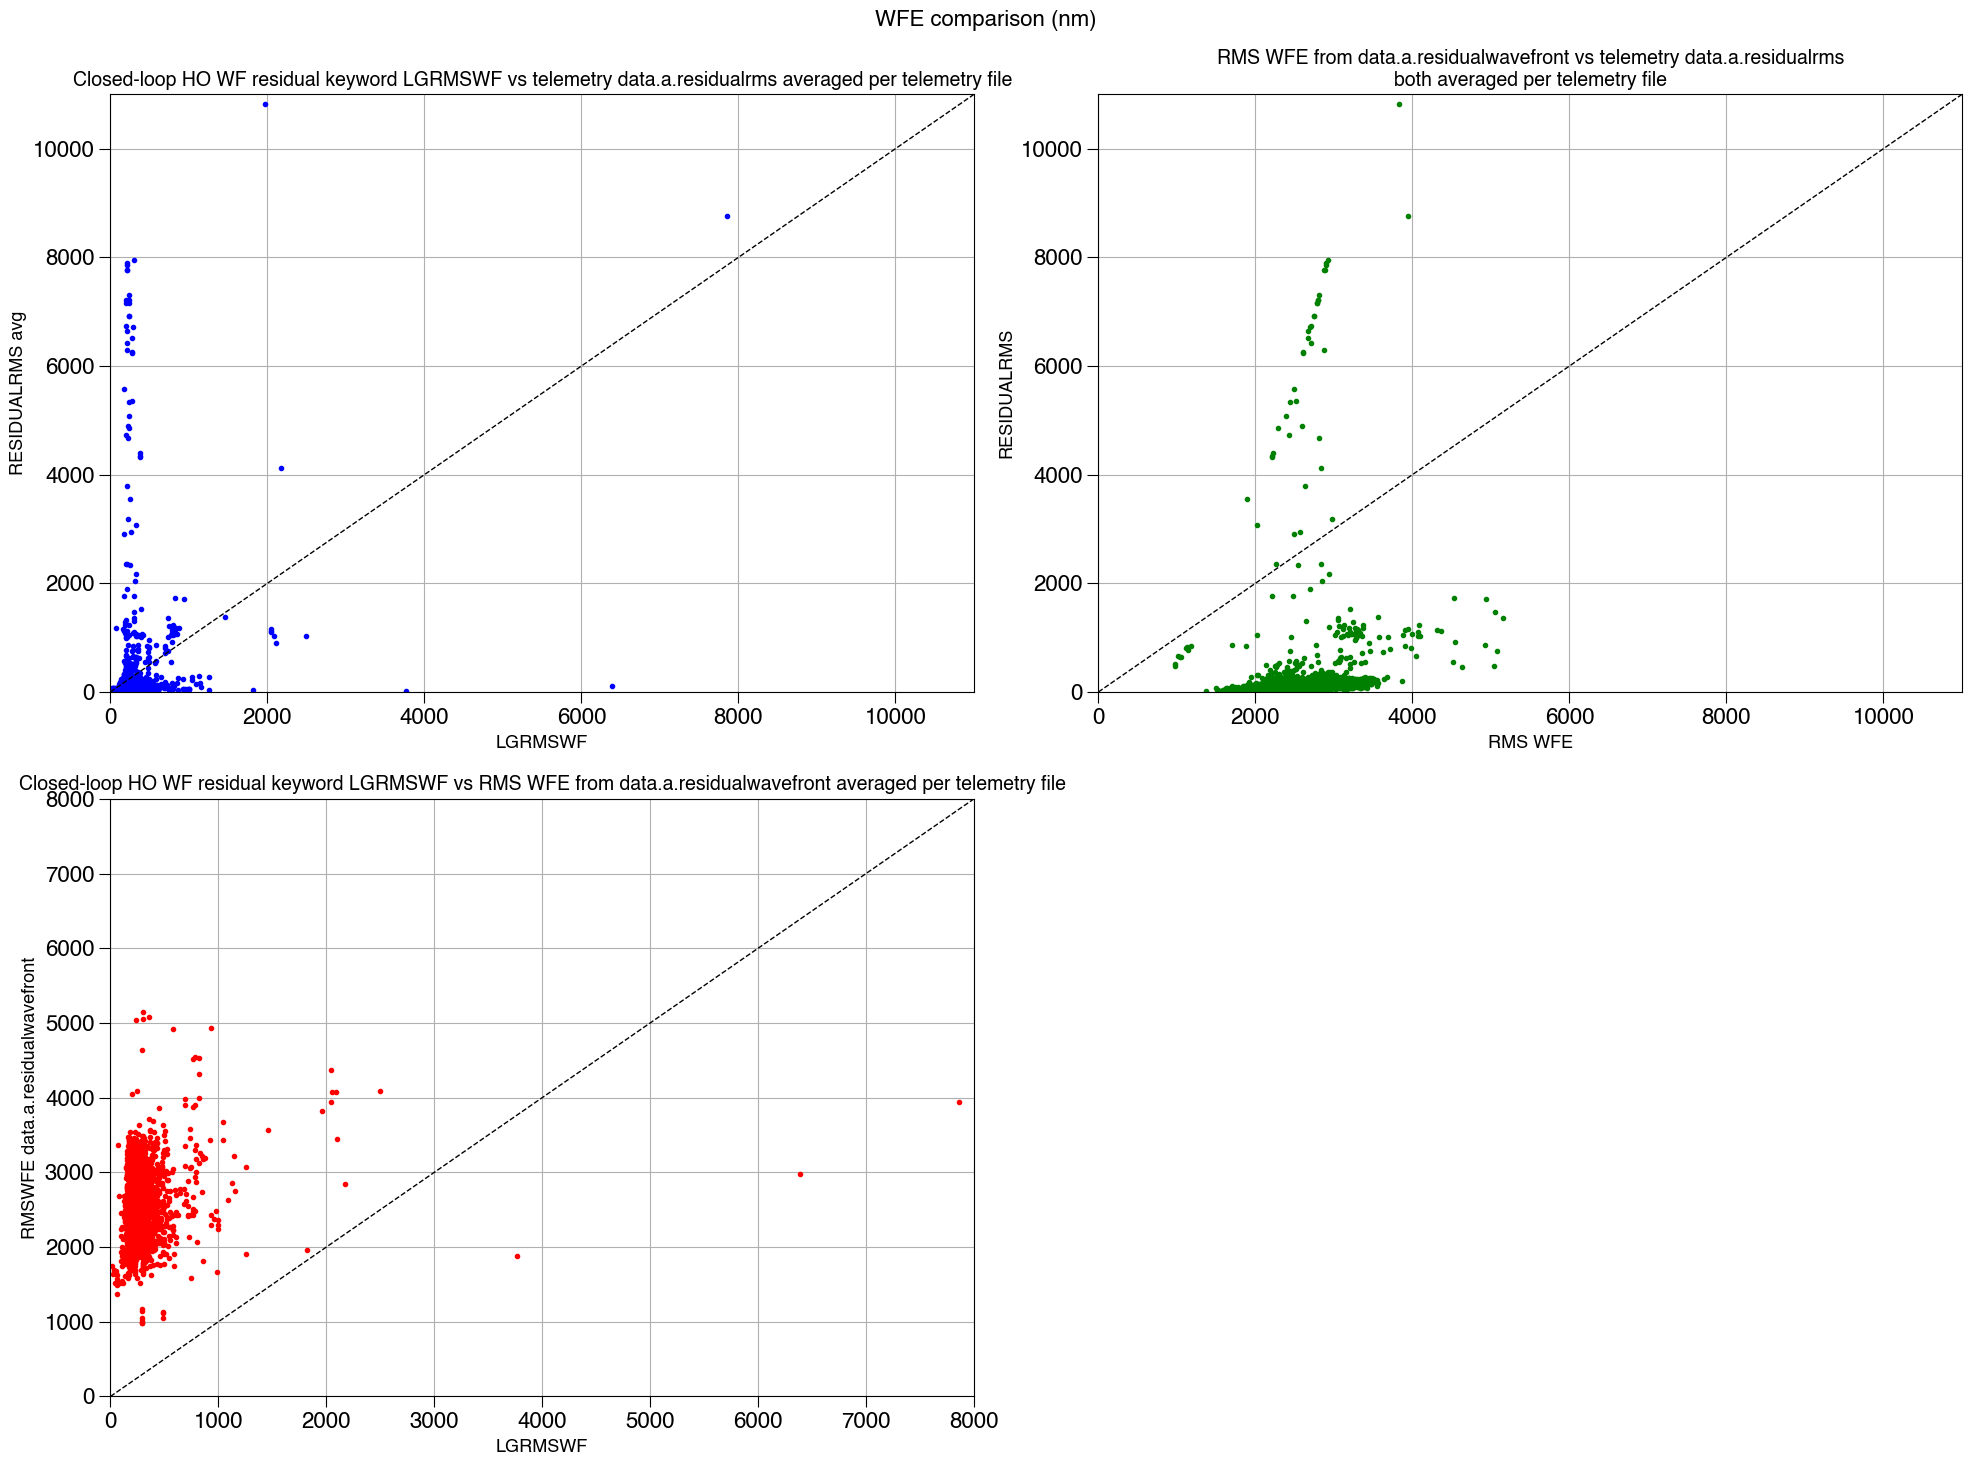

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes[0, 0].plot(cleaned_telem['LGRMSWFs'].astype(float), cleaned_telem['RESIDUALRMS'].astype(float), '.', color="blue")
axes[1, 0].plot(cleaned_telem['LGRMSWFs'].astype(float), cleaned_telem['RMSWFE'].astype(float), '.', color="red")
axes[0, 1].plot(cleaned_telem['RMSWFE'].astype(float), cleaned_telem['RESIDUALRMS'].astype(float), '.', color="green")
axes[1, 1].remove()
axes[0, 0].set_title("Closed-loop HO WF residual keyword LGRMSWF vs telemetry data.a.residualrms averaged per telemetry file", fontsize=14)
axes[0, 0].set_xlabel("LGRMSWF", fontsize=13)
axes[0, 0].set_ylabel("RESIDUALRMS avg", fontsize=13)
axes[1, 0].set_title("Closed-loop HO WF residual keyword LGRMSWF vs RMS WFE from data.a.residualwavefront averaged per telemetry file", fontsize=14)
axes[1, 0].set_xlabel("LGRMSWF", fontsize=13)
axes[1, 0].set_ylabel("RMSWFE data.a.residualwavefront", fontsize=13)
axes[0, 1].set_title("RMS WFE from data.a.residualwavefront vs telemetry data.a.residualrms\nboth averaged per telemetry file", fontsize=14)
axes[0, 1].set_xlabel("RMS WFE", fontsize=13)
axes[0, 1].set_ylabel("RESIDUALRMS", fontsize=13)
axes[0, 0].grid(True)
axes[0, 1].grid(True)
axes[1, 0].grid(True)
axes[0, 0].axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
axes[0, 1].axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
axes[1, 0].axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
axes[0, 0].set_xlim(0.0, 11000.0)
axes[0, 0].set_ylim(0.0, 11000.0)
axes[0, 1].set_xlim(0.0, 11000.0)
axes[0, 1].set_ylim(0.0, 11000.0)
axes[1, 0].set_xlim(0.0, 8000.0)
axes[1, 0].set_ylim(0.0, 8000.0)
plt.suptitle("WFE comparison (nm)", fontsize=16)
plt.tight_layout()
plt.show()

##### Histogram

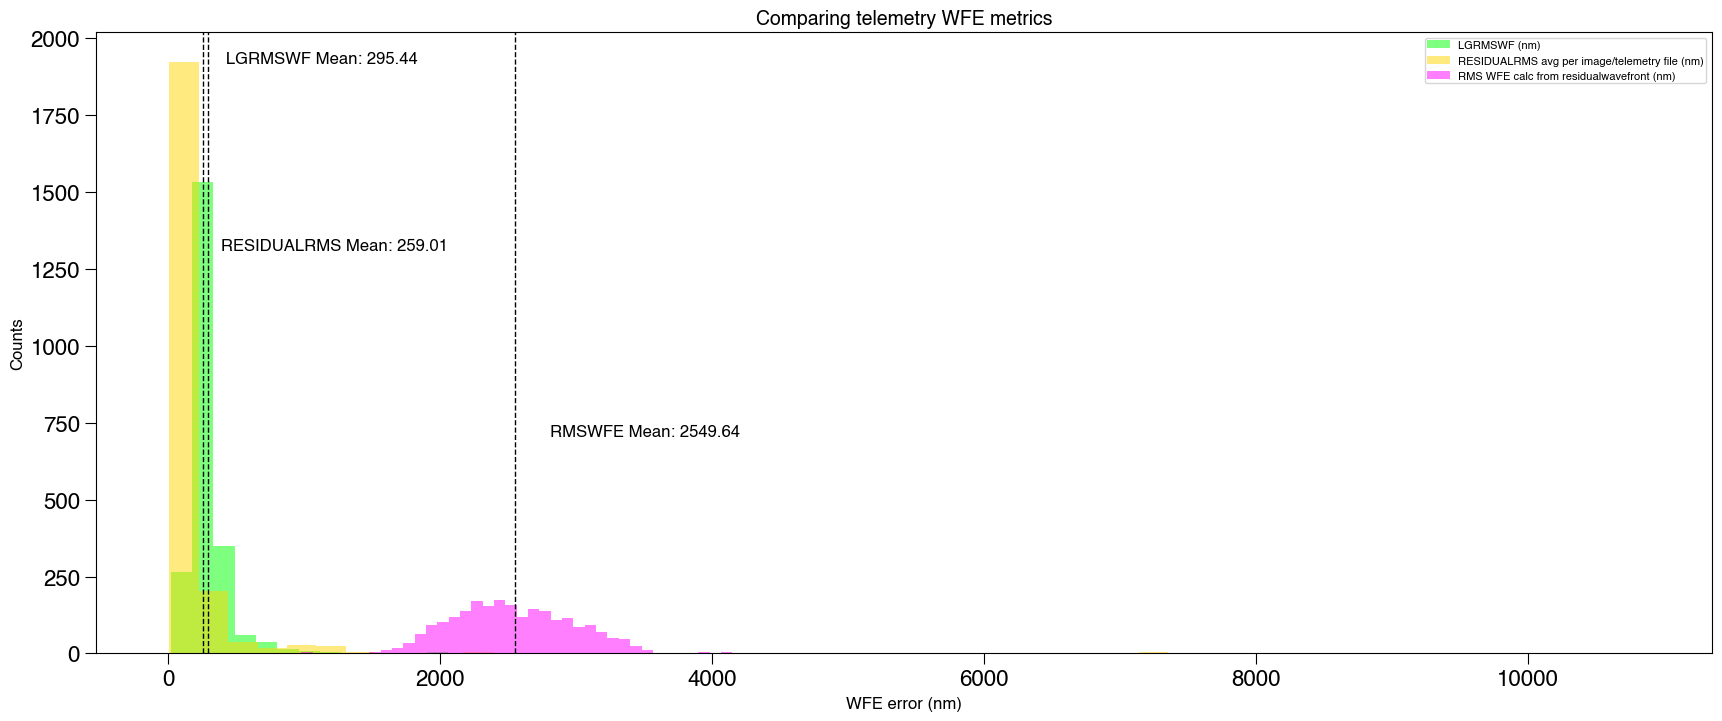

In [57]:
fig, axes = plt.subplots(figsize=(17.5, 7.5))
plt.hist(cleaned_telem['LGRMSWFs'].astype(float), bins=50, color="lime", alpha=0.5, label="LGRMSWF (nm)")
plt.hist(cleaned_telem['RESIDUALRMS'].astype(float), bins=50, color="gold", alpha=0.5, label="RESIDUALRMS avg per image/telemetry file (nm)")
plt.hist(cleaned_telem['RMSWFE'].astype(float), bins=50, color="magenta", alpha=0.5, label="RMS WFE calc from residualwavefront (nm)")
plt.title("Comparing telemetry WFE metrics", fontsize=14)
plt.xlabel("WFE error (nm)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.legend(fontsize=8)
plt.tight_layout()
min_ylim, max_ylim = plt.ylim()
plt.text(cleaned_telem['LGRMSWFs'].astype(float).mean()*1.1, max_ylim*0.95, 
         '\t\t\tLGRMSWF Mean: {:.2f}'.format(cleaned_telem['LGRMSWFs'].astype(float).mean()),
         fontsize=12)
plt.axvline(cleaned_telem['LGRMSWFs'].astype(float).mean(), color='k', 
            linestyle='dashed', linewidth=1)
plt.text(cleaned_telem['RESIDUALRMS'].astype(float).mean()*1.1, max_ylim*0.65, 
         '\t\t\tRESIDUALRMS Mean: {:.2f}'.format(cleaned_telem['RESIDUALRMS'].astype(float).mean()),
         fontsize=12)
plt.axvline(cleaned_telem['RESIDUALRMS'].astype(float).mean(), color='k', 
            linestyle='dashed', linewidth=1)
plt.text(cleaned_telem['RMSWFE'].astype(float).mean()*1.1, max_ylim*0.35, 
         'RMSWFE Mean: {:.2f}'.format(cleaned_telem['RMSWFE'].astype(float).mean()),
         fontsize=12)
plt.axvline(cleaned_telem['RMSWFE'].astype(float).mean(), color='k', 
            linestyle='dashed', linewidth=1)
plt.show()

#### **Compare ``APD_SKY_BACK`` with ``powfs.bkgrnd[STRAP]``**
units unclear because ``APD_SKY_BACK`` is not defined in the telemetry KAON, so it is not clear if the ``STRAP`` background input into ``MAOS`` has the same units

In [58]:
apd_bkgrnds = cleaned_telem['APD_SKY_BACK'].astype(float)
strap_bkgrnd = cleaned_telem['STRAP BKGRND'].astype(float) # sky background in e/pixel/frame at integration time sim.dtref

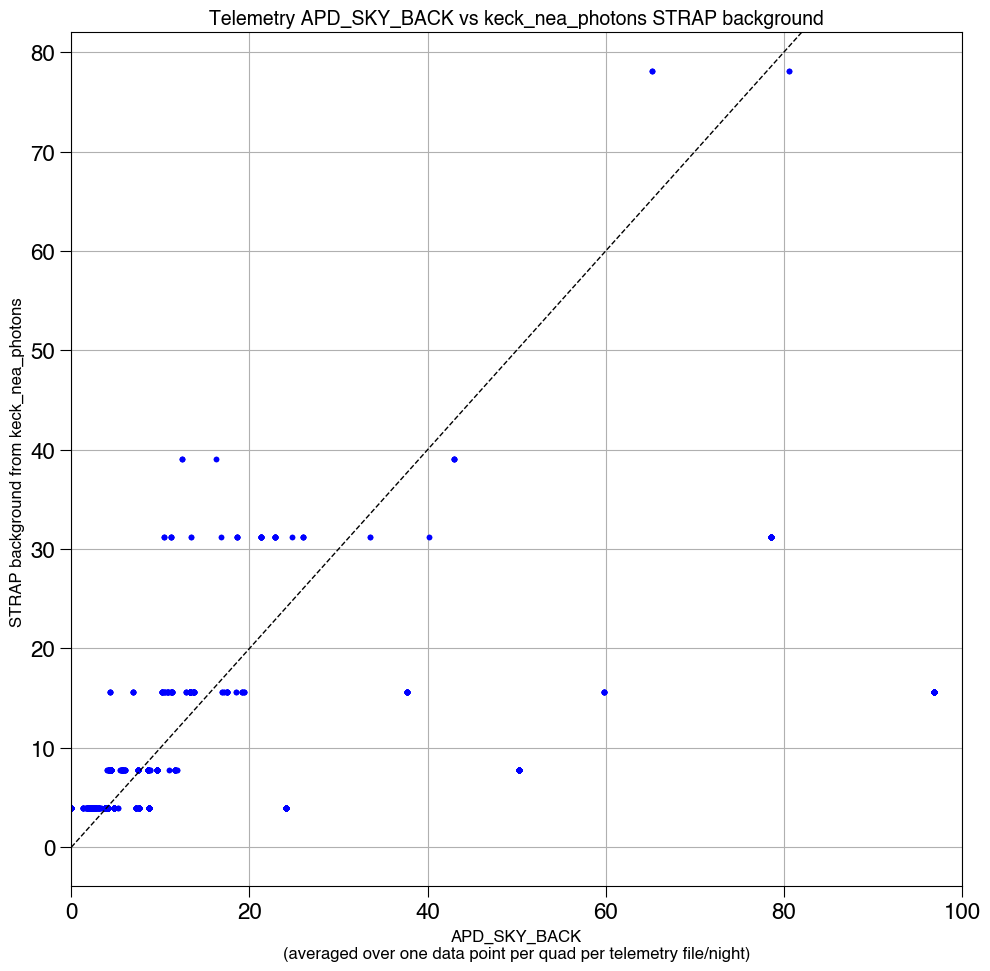

In [59]:
fig, axes = plt.subplots(figsize=(10, 10))
plt.plot(apd_bkgrnds, strap_bkgrnd, '.', color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
plt.title("Telemetry APD_SKY_BACK vs keck_nea_photons STRAP background", fontsize=14)
plt.xlabel("APD_SKY_BACK\n(averaged over one data point per quad per telemetry file/night)", fontsize=12)
plt.ylabel("STRAP background from keck_nea_photons ", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.xlim(0.0, 100.0)
plt.show()

Could it be that ``APD_SKY_BACK`` needs to be converted from counts to electrons via the STRAP gain? I'm not sure what that is (Jim said he would need vendor report), but perhaps it is one of the TT GAIN keywords

In [60]:
apd_dtgain = (cleaned_telem['APD_SKY_BACK']*cleaned_telem['DTGAIN']).astype(float)
apd_utgain = (cleaned_telem['APD_SKY_BACK']*cleaned_telem['UTGAIN']).astype(float)

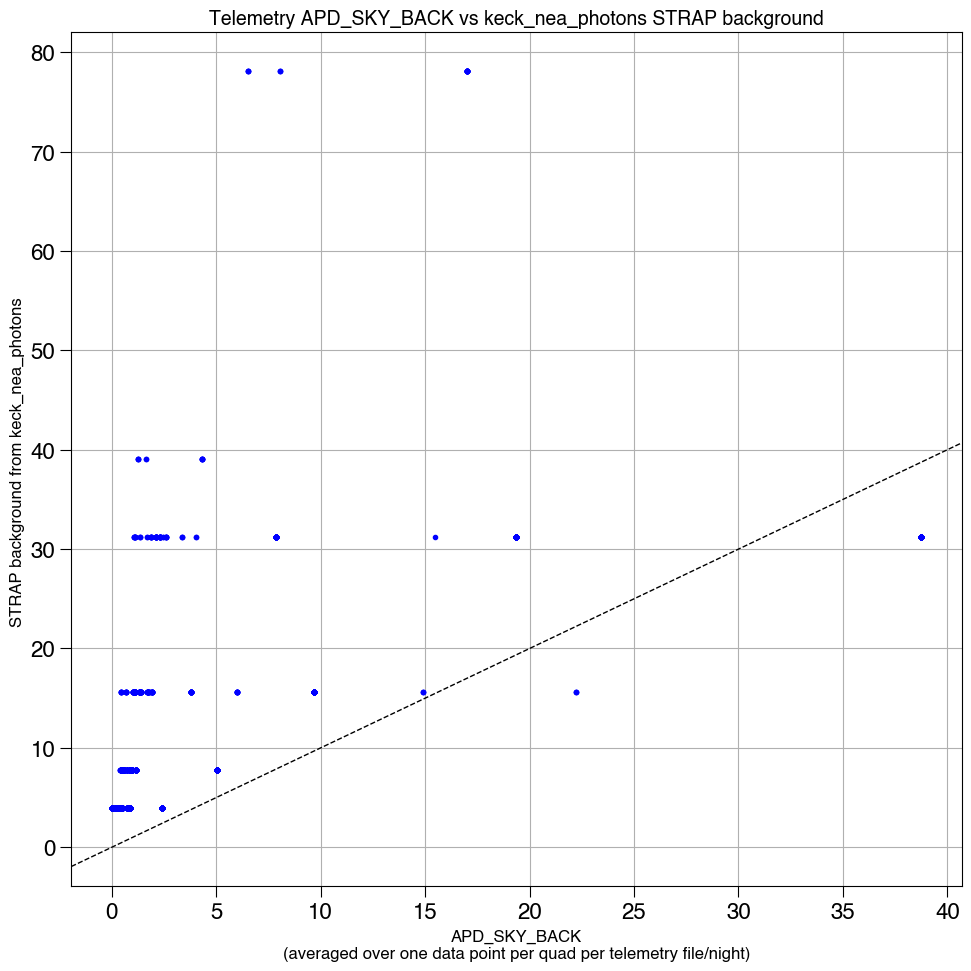

In [61]:
fig, axes = plt.subplots(figsize=(10, 10))
plt.plot(apd_utgain, strap_bkgrnd, '.', color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
plt.title("Telemetry APD_SKY_BACK vs keck_nea_photons STRAP background", fontsize=14)
plt.xlabel("APD_SKY_BACK\n(averaged over one data point per quad per telemetry file/night)", fontsize=12)
plt.ylabel("STRAP background from keck_nea_photons ", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.show()

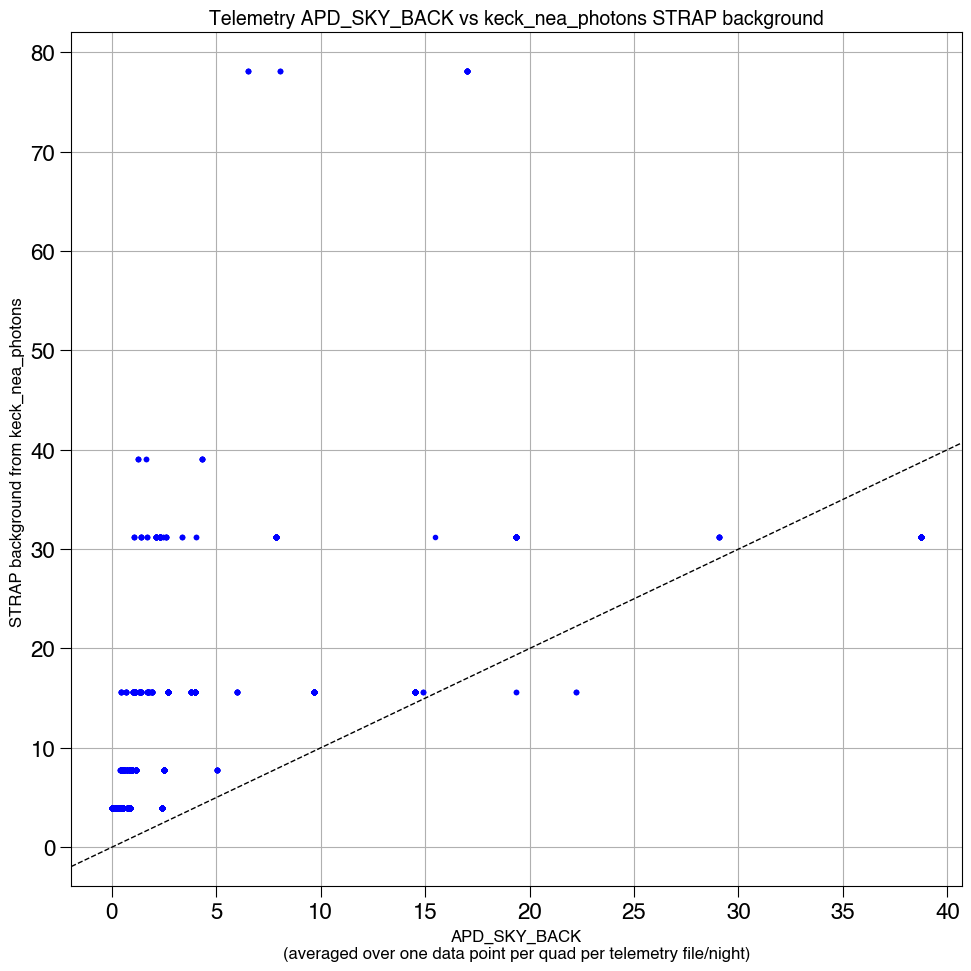

In [62]:
fig, axes = plt.subplots(figsize=(10, 10))
plt.plot(apd_dtgain, strap_bkgrnd, '.', color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
plt.title("Telemetry APD_SKY_BACK vs keck_nea_photons STRAP background", fontsize=14)
plt.xlabel("APD_SKY_BACK\n(averaged over one data point per quad per telemetry file/night)", fontsize=12)
plt.ylabel("STRAP background from keck_nea_photons ", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.show()

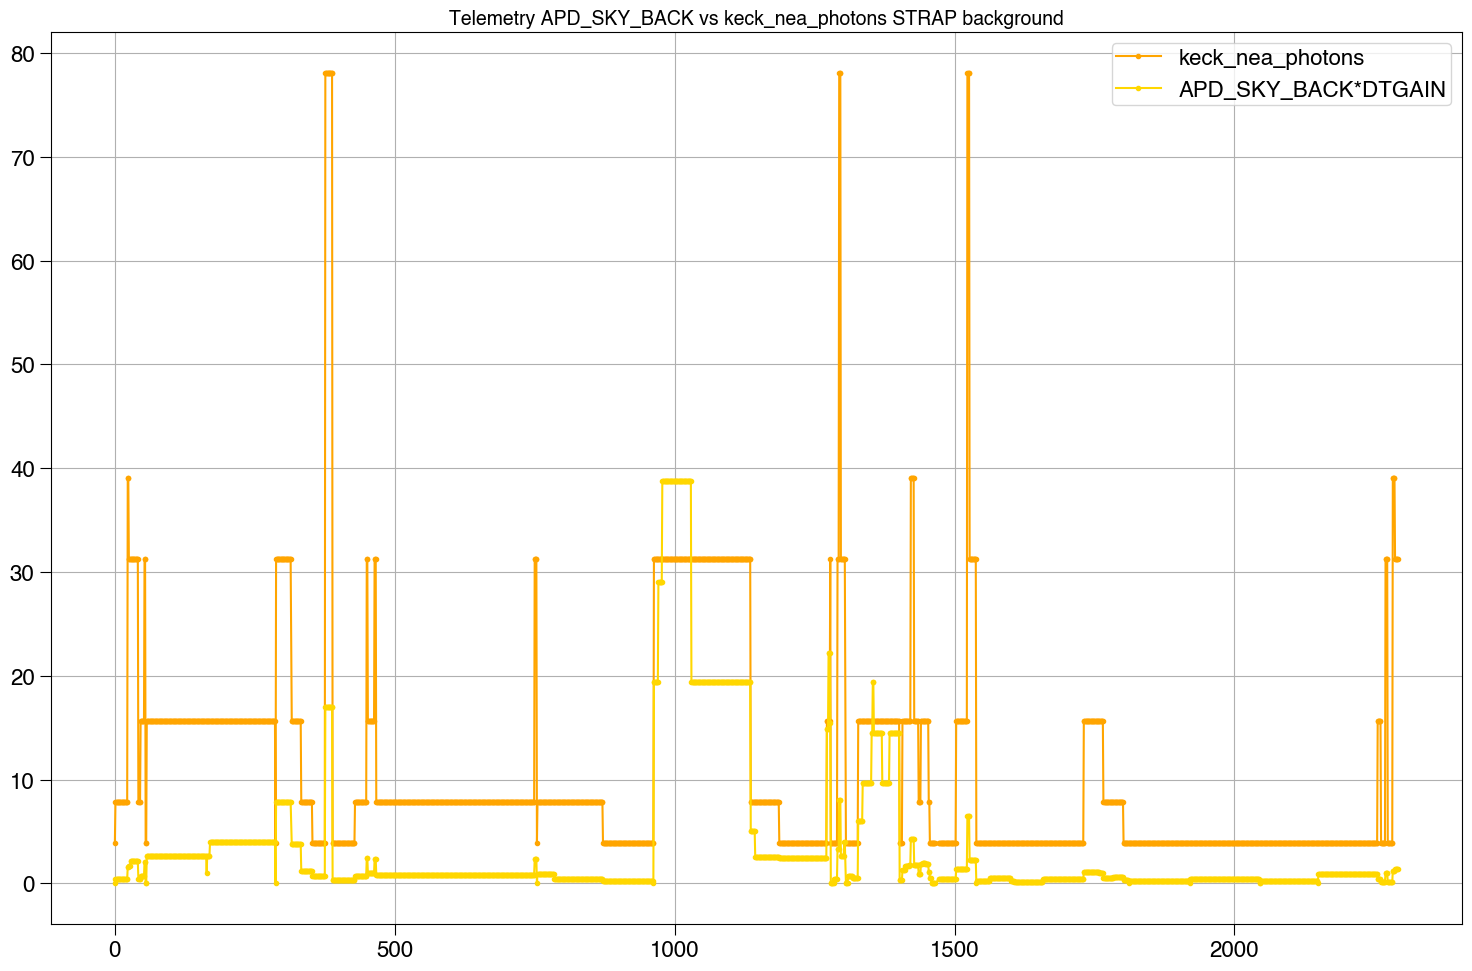

In [63]:
fig, axes = plt.subplots(figsize=(15, 10))
# plt.plot(apd_bkgrnds, '.-', color="red", label="APD_SKY_BACK")
plt.plot(strap_bkgrnd, '.-', color="orange", label="keck_nea_photons")
plt.plot(apd_dtgain, '.-', color="gold", label="APD_SKY_BACK*DTGAIN")
# plt.plot(apd_utgain, '.-', color="green", label="APD_SKY_BACK*UTGAIN")
plt.title("Telemetry APD_SKY_BACK vs keck_nea_photons STRAP background", fontsize=14)
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()

#### **Compare ``keck_nea_photon(...)`` output for ``MAOS`` input ``powfs.siglev[SHWFS, STRAP]`` to ``STRAPDQMN`` and ``SUBAPINTENSITY`` telemetry**

In [64]:
strap_siglev = cleaned_telem['STRAP SIGLEV'].astype(float) # units in MAOS unclear, MAOS performance doc gives 'Signal level in e- per subaperture per exposure at integration time sim.dtref for each WFS'
shwfs_siglev = cleaned_telem['SHWFS SIGLEV'].astype(float) # units in MAOS unclear
shwfs_bkgrnd = cleaned_telem['SHWFS BKGRND'].astype(float) # sky background in e/pixel/frame at integration time sim.dtref

# STRAPDQMN is quad mean APD counts

#### **APDCOUNTS and STRAPDQMN comparison to investigate unknown gain settings**

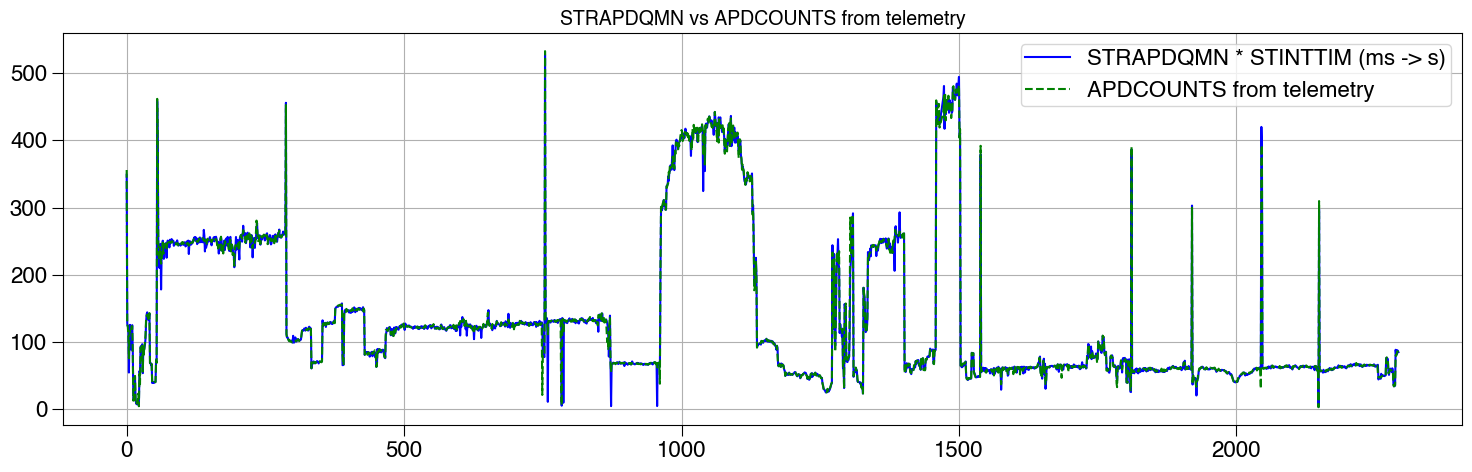

In [65]:
fig, axes = plt.subplots(figsize=(15, 5))
plt.plot(cleaned_telem['STRAPDQMNs'].astype(float)*cleaned_telem['STINTTIMs'].astype(float)*0.001, label="STRAPDQMN * STINTTIM (ms -> s)", color="blue")
plt.plot(cleaned_telem['APDCOUNTS'].astype(float), label="APDCOUNTS from telemetry", color="green", linestyle="--")
plt.title("STRAPDQMN vs APDCOUNTS from telemetry", fontsize=14)
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()

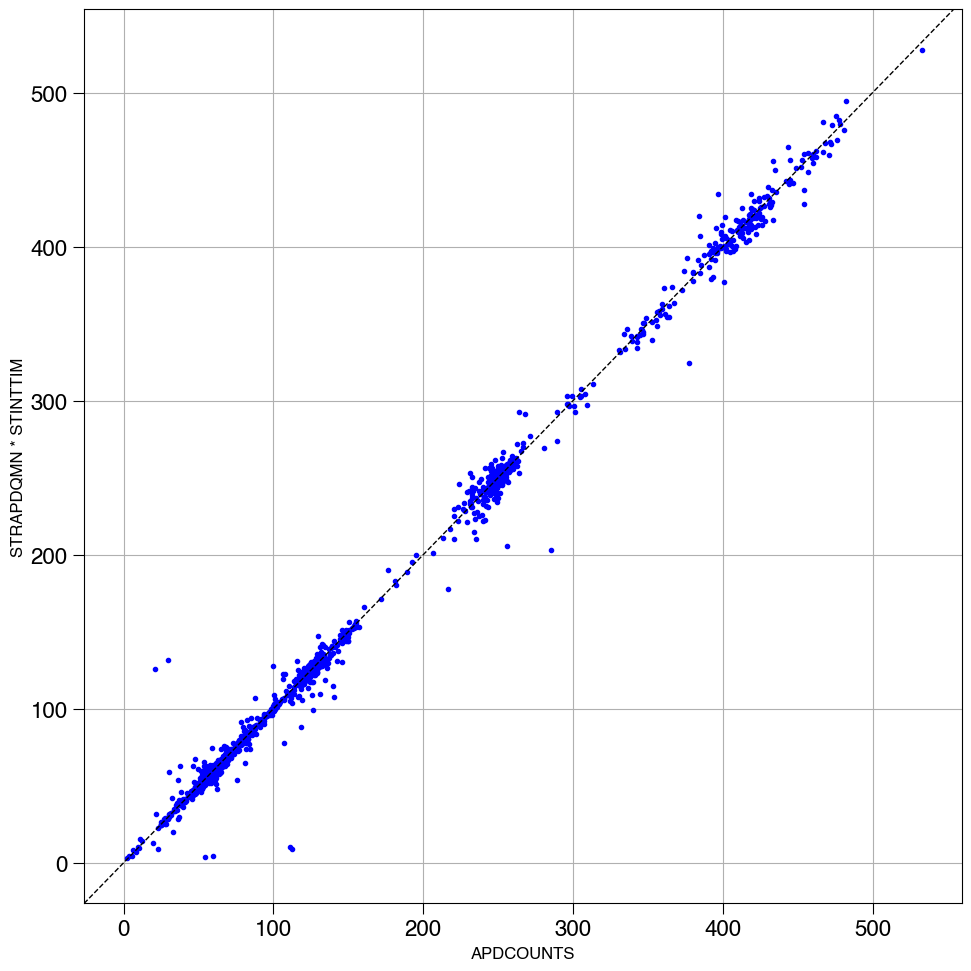

In [66]:
fig, axes = plt.subplots(figsize=(10, 10))
plt.plot(cleaned_telem['APDCOUNTS'].astype(float), cleaned_telem['STRAPDQMNs'].astype(float)*cleaned_telem['STINTTIMs'].astype(float)*0.001, '.', color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
plt.xlabel("APDCOUNTS", fontsize=12)
plt.ylabel("STRAPDQMN * STINTTIM", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.show()

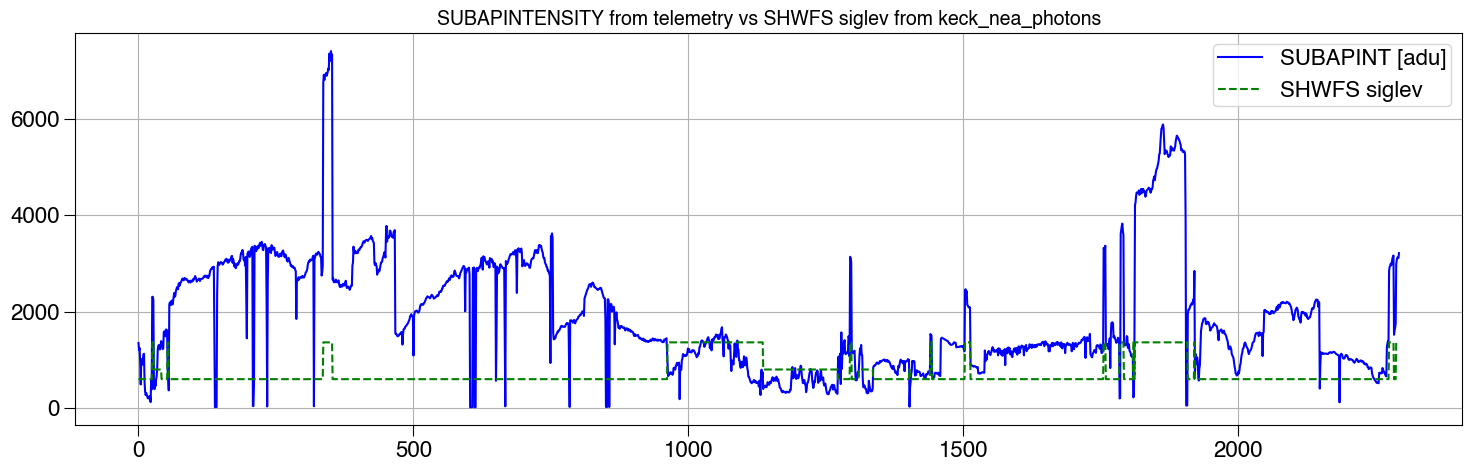

In [67]:
fig, axes = plt.subplots(figsize=(15, 5))
plt.plot(cleaned_telem['SUBAPINTs'].astype(float), label="SUBAPINT [adu]", color="blue")
plt.plot(cleaned_telem['SHWFS SIGLEV'].astype(float), label="SHWFS siglev", color="green", linestyle="--")
plt.title("SUBAPINTENSITY from telemetry vs SHWFS siglev from keck_nea_photons", fontsize=14)
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()

In [68]:
cleaned_telem['filename'][349]
# np.argmax(cleaned_telem['SUBAPINTs'].astype(float))

'/g/lu/data/keck_telemetry/20170505/sdata901/nirc16/2017may05/n0279_LGS_trs.sav'

#### **Subaperture evaluation using handful of telemetry files**

In [118]:
sample1 = readsav(telemetry['filename'][1900])
# sample2 = readsav(telemetry['filename'][1600])
# sample3 = readsav(telemetry['filename'][1700])

In [119]:
offset_centroid_std = np.sqrt(np.std(sample1.a.offsetcentroid[0][:,range(0, 608, 2)], axis = 0)**2 + np.std(sample1.a.offsetcentroid[0][:,range(1, 608, 2)])**2)
subapint_std = np.std(sample1.a.subapintensity[0][:,].astype(float), axis=0)

# Calculate subaperture intensity median over time for each actuator
median_flux_timestream = np.median(sample1.a.subapintensity[0][:,].astype(float), axis=0)
print(f"Median SUBAPINTENSITY [adu] = {median_flux_timestream}")
print(f"Median SUBAPINTENSITY [adu] = {np.median(median_flux_timestream)}")
print(f"Median taken directly over time and actuators = {np.median(sample1.a.subapintensity[0])}")

Median SUBAPINTENSITY [adu] = [ 149.  164.  192.  188.  943.  685.  385. 2057.  347. 2192. 4359. 2774.
 6203. 6952. 1082.  137. 4828. 3643. 5064. 6767. 5486. 7395. 7284. 6925.
 7536. 7678. 3153.  187.  129.  115. 4363. 7013. 7817. 7177. 7383. 6976.
 6660. 6780. 6902. 7275. 6225. 4958. 3391.  352.  120.  103. 3654. 7244.
 7312. 7418. 7221. 7039. 6520. 6994. 7368. 7369. 5555. 4722. 4753. 1105.
  148.  107. 2554. 6758. 6942. 7279. 7557. 7198. 7543. 6921. 7672. 7597.
 7637. 6546. 4965. 4926. 6464. 3380.  147.   92. 3718. 7000. 7087. 7197.
 7414. 7195. 7277. 6489. 6764. 7069. 7370. 7565. 6967. 7287. 7768. 6809.
  311.  103.  218. 4602. 6708. 6920. 7366. 7241. 7435. 7576. 5411. 6888.
 7827. 7135. 6861. 7584. 7250. 7365. 7038. 5136. 1876.   92. 3851. 7408.
 7659. 6607. 6822. 6799. 7208. 4809.  502. 6821. 7518. 7326. 7477. 7268.
 7782. 7674. 5007.  123. 3465. 7417. 7322. 7602. 7318. 7259. 5831.  450.
 8023. 6787. 7607. 7427. 7310. 7420. 3471.  109. 6113. 7021. 7070. 7479.
 7095. 7695. 7268.  5

In [120]:
subapint_med = np.median(median_flux_timestream)
subapint_mean = np.mean(sample1.a.subapintensity[0][:,].astype(float), axis=0)

In [121]:
# Find where time averaged intensity of each subaperture is less than
# 30% of median value
print(0.3*subapint_med)
bad_subap = np.where(subapint_mean < 0.3*subapint_med)

2071.2


In [122]:
bad_subap = bad_subap[0]

[autoreload of paarti.utils.maos_utils failed: Traceback (most recent call last):
  File "/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/opt/mambaforge3/envs/astro/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/u/bdigia/code/python/paarti/paarti/utils/maos_utils.py", line 3773
    d

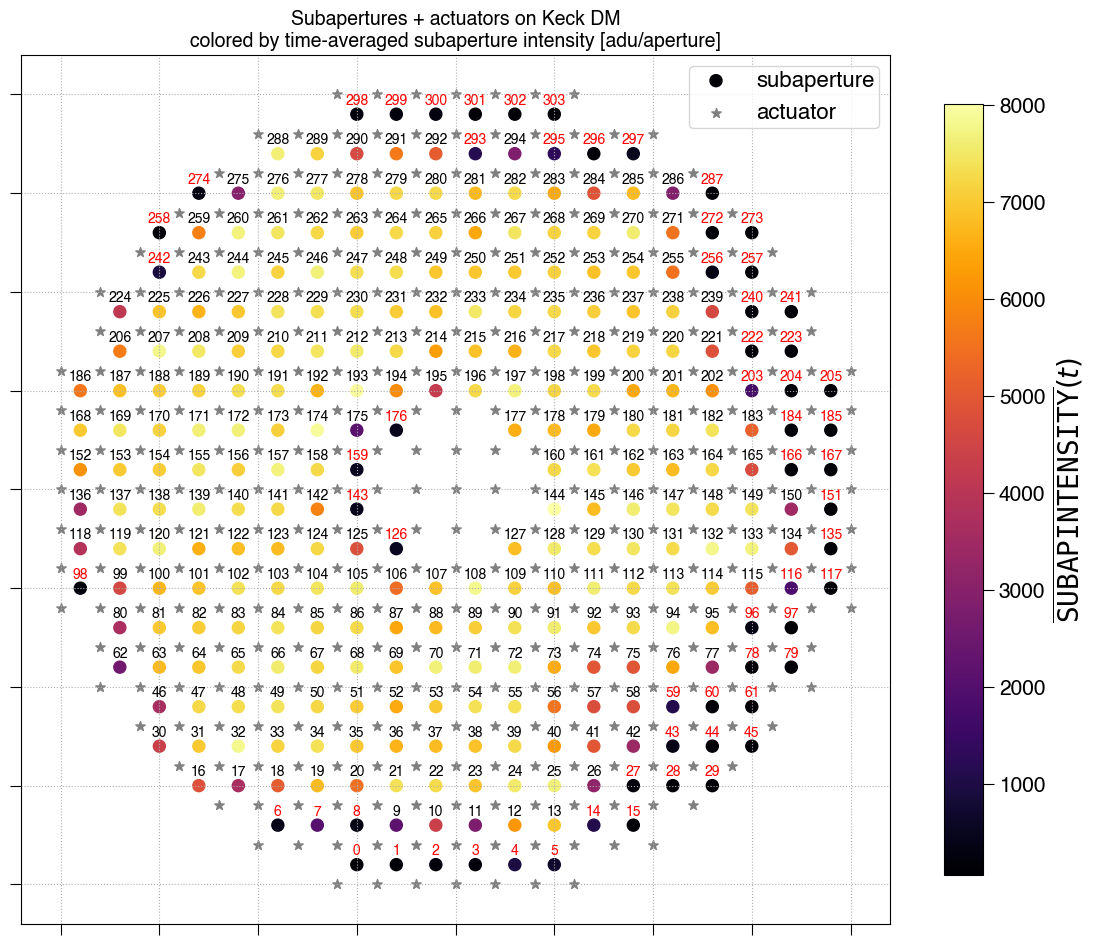

In [136]:
import matplotlib as mpl
sub_aperture_map = open("sub_ap_map.txt", 'r')
actuator_map = open("actuator_map.txt", 'r')

exact_x = []
exact_y = []
start_y = 0.1
act_x = []
act_y = []
start_act_y = 0.0

for info in sub_aperture_map.readlines():
    start_x = 0.1
    line = list(info)
    for i in line:
        if (i != " ") & (i != '\n'):
            if int(i) != 0:
                exact_x.append(start_x)
                exact_y.append(start_y)
            start_x += 0.2
    start_y += 0.2

for info in actuator_map.readlines():
    start_x = 0.0
    line = list(info)
    for i in line:
        if (i != " ") & (i != '\n'):
            if int(i) != 0:
                act_x.append(start_x)
                act_y.append(start_act_y)
            start_x += 0.2
    start_act_y += 0.2

cmap = mpl.cm.inferno
str_txt = [str(i) for i in range(304)]
fig, axes = plt.subplots(figsize=(11.5, 11.5))
im = plt.scatter(exact_x, exact_y, label="subaperture", alpha=1.0, c=pd.Series(subapint_mean), cmap=cmap, s=75)
axes.set_aspect('equal')
fig.colorbar(im, ax=axes, label=r'$\overline{\mathtt{SUBAPINTENSITY}}(t)$', shrink=0.7)
i = 0
while i < 304:
    if i in bad_subap:
        axes.text(exact_x[i], exact_y[i] + 0.05, str_txt[i], horizontalalignment='center', fontsize=10, color="red")
    else:
        axes.text(exact_x[i], exact_y[i] + 0.05, str_txt[i], horizontalalignment='center', fontsize=10, color="black")
    i += 1

cbar = plt.gcf()
cbar_ax = cbar.axes[-1]
cbar_ax.tick_params(axis="both", labelsize=15)
cbar_ax.set_frame_on(True)

str_txt = [str(i) for i in range(349)]
plt.scatter(act_x, act_y, color="grey", label="actuator", alpha=1.0, marker="*", s=50)
# i = 0
# while i < 349:
#     axes.text(act_x[i], act_y[i] - 0.1, str_txt[i], horizontalalignment='center', fontsize=10, color="black")
#     i += 1

# axes.set_xlabel('X', fontsize = 12)
# axes.set_ylabel('Y', fontsize = 12)
axes.set_title("Subapertures + actuators on Keck DM\ncolored by time-averaged subaperture intensity [adu/aperture]", fontsize=14)
# Turn off tick labels
axes.set_yticklabels([])
axes.set_xticklabels([])
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='dotted')

In [124]:
med_per_subap = np.median(sample1.a.subapintensity[0][:,].astype(float), axis=0)
# Calculate subaperture intensity statistics
subapint_std = np.std(sample1.a.subapintensity[0][:,].astype(float), axis=0)
subapint_med = np.median(med_per_subap)
subapint_mean = np.mean(sample1.a.subapintensity[0][:,].astype(float), axis=0)
median_flux_timestream = np.median(sample1.a.subapintensity[0][:,].astype(float), axis=0)
print(f"Median SUBAPINTENSITY [adu] = {median_flux_timestream}")
print(f"Median SUBAPINTENSITY [adu] = {np.median(median_flux_timestream)}")
# Find where time averaged intensity of each subaperture is less than
# 30% of median value
bad_subap = np.where(subapint_mean < 0.3*subapint_med)[0]
# Load sub aperture and actuator maps for Keck DM
subapmap = mu.load_sub_ap_map().astype(int)
actmap = mu.load_act_map().astype(int)
# Turn sub-apertures off (1 -> 0) in sub aperture map if sub aperture is selected as bad
subap_index = -1 # (start at -1 because there is a subaperture labeled 0 itself)
for row in range(subapmap.shape[0]-1, -1, -1):
    for col in range(subapmap.shape[1]):
        # print(subap[row, col])
        # Track subapertures with special separate index that 
        # only counts the 1s (subapertures) in the subap map
        if subapmap[row,col] == 1:
            subap_index += 1
            # With subaperture index updated, evaluate subaperture within
            # ORIGINAL subaperture map
            if subap_index in bad_subap:
                # Turn bad subaperture 'off' by setting it to 0 (it is
                # no longer considered a subaperture in union map below)
                subapmap[row, col] = 0
# Pad map with one row and one column of 0s, will be elimated during subsequent logic operations
temp = np.c_[subapmap, np.zeros(subapmap.shape[0])]
exp = np.r_[temp, [np.zeros(temp.shape[1])]]
# Find which corresponding actuators need to be masked as well
union = np.bitwise_and(actmap, exp.astype(int))
# Trim off 0 pads post-union
bad_act = union[:-1,:-1]

Median SUBAPINTENSITY [adu] = [ 149.  164.  192.  188.  943.  685.  385. 2057.  347. 2192. 4359. 2774.
 6203. 6952. 1082.  137. 4828. 3643. 5064. 6767. 5486. 7395. 7284. 6925.
 7536. 7678. 3153.  187.  129.  115. 4363. 7013. 7817. 7177. 7383. 6976.
 6660. 6780. 6902. 7275. 6225. 4958. 3391.  352.  120.  103. 3654. 7244.
 7312. 7418. 7221. 7039. 6520. 6994. 7368. 7369. 5555. 4722. 4753. 1105.
  148.  107. 2554. 6758. 6942. 7279. 7557. 7198. 7543. 6921. 7672. 7597.
 7637. 6546. 4965. 4926. 6464. 3380.  147.   92. 3718. 7000. 7087. 7197.
 7414. 7195. 7277. 6489. 6764. 7069. 7370. 7565. 6967. 7287. 7768. 6809.
  311.  103.  218. 4602. 6708. 6920. 7366. 7241. 7435. 7576. 5411. 6888.
 7827. 7135. 6861. 7584. 7250. 7365. 7038. 5136. 1876.   92. 3851. 7408.
 7659. 6607. 6822. 6799. 7208. 4809.  502. 6821. 7518. 7326. 7477. 7268.
 7782. 7674. 5007.  123. 3465. 7417. 7322. 7602. 7318. 7259. 5831.  450.
 8023. 6787. 7607. 7427. 7310. 7420. 3471.  109. 6113. 7021. 7070. 7479.
 7095. 7695. 7268.  5

In [125]:
# subaperure map with bad actuators masked (turned to 0)
print(subapmap)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [126]:
print(bad_act)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [127]:
np.array_equal(bad_act, union)

False

In [94]:
actmap.shape

(21, 21)

--------------------

#### 'Knee' frequencies

where break in power spectra (FFT) of telemetry streams occurs

In [13]:
# # Collect telemetry durations and average time spacing for A and B objects
# # within each data object
# time_data = np.empty((len(data_list), 3))
# for i, data in enumerate(data_list):
#     start_time = data.a.timestamp[0][0] * 100.0 # in ns
#     stop_time = data.a.timestamp[0][-1] * 100.0 # in ns
#     tint = (stop_time - start_time) * 1.0e-9
#     # Store duration of telemetry in seconds
#     time_data[i][0] = tint
#     # Average data.b time spacing 
#     time_data[i][1] = np.mean(np.diff(data.b.timestamp[0])) * 100.0 * (1e-9) # seconds
#     # Average data.a time spacing
#     time_data[i][2] = np.mean(np.diff(data.a.timestamp[0])) * 100.0 * (1e-9) # seconds

In [64]:
# Grab actual telemetry data objects
data_list = []
for i, path in enumerate(paths[:-1:100]):
    print(f"{path}")
    sample1 = readsav(path)
    data_list.append(sample1)

/g/lu/data/keck_telemetry/20170718/sdata901/nirc15/2017jul18/n0098_LGS_trs.sav
/g/lu/data/keck_telemetry/20170504/sdata903/nirc15/2017may04/n0051_LGS_trs.sav
/g/lu/data/keck_telemetry/20170504/sdata903/nirc15/2017may04/n0151_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata901/nirc16/2017may05/n0229_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata901/nirc16/2017may05/n0329_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0035_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0135_LGS_trs.sav
/g/lu/data/keck_telemetry/20170505/sdata904/nirc15/2017may05/n0235_LGS_trs.sav
/g/lu/data/keck_telemetry/20170727/sdata902/nirc20/2017jul27/n0590_LGS_trs.sav
/g/lu/data/keck_telemetry/20170727/sdata902/nirc20/2017jul27/n0690_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017aug08/n0110_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017aug08/n0210_LGS_trs.sav
/g/lu/data/keck_telemetry/20170808/sdata904/nirc7/2017

In [ ]:
# According to KAON 1165 AO Telemetry, DTTCENTROIDS is a measure of the TT 
# residual in arcsec
ttcentroids_x = sample1.b.dttcentroids[0][:,0]
ttcentroids_y = sample1.b.dttcentroids[0][:,1]

In [ ]:
# indices = np.argsort(freq)[:100]
# S = Sensitivity = 1.0 as suggested by kneed docs, concave curve to locate knee point, increasing direction for positive slope
kneedle_pol = kneed.KneeLocator(freq, np.abs(tt_pol_ffty), S=1.0, curve='convex', 
                            direction='decreasing', interp_method='polynomial', 
                            polynomial_degree=6)
kneedle_cl = kneed.KneeLocator(freq, np.abs(ttcentroids_ffty), S=1.0, curve='concave', 
                            direction='increasing', interp_method='polynomial', 
                            polynomial_degree=8)
elbow = kneedle_pol.elbow # the returned knee point is the value on the x-axis (frequency)
print(f'Elbow using pseudo-open-loop curve: {elbow} Hz')
knee = kneedle_cl.knee
print(f'Knee using closed-loop curve: {knee} Hz')
kneedle_pol.plot_knee_normalized(title='Pseudo Open Loop')
kneedle_cl.plot_knee_normalized(title='Closed Loop')

plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.semilogy(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.axvline(x=elbow, linestyle='--', color='black')
plt.axvline(x=knee, linestyle='-.', color='black')
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()

### Calculate RMS Wavefront Error
using equation 8 from https://opg.optica.org/oe/fulltext.cfm?uri=oe-32-1-301&id=54465, implemented in MAOS_UTILS

### Plot RMS Residuals for SHWFS 

In [290]:

for i, sample1 in enumerate(data_list):
    residualwavefrnt = np.transpose(sample1.a.residualwavefront[0])
    residualwavefrnt[0]

array([1.5498906 , 1.3510566 , 0.7784645 , ..., 1.7675025 , 0.79494905,
       1.4993864 ], dtype=float32)

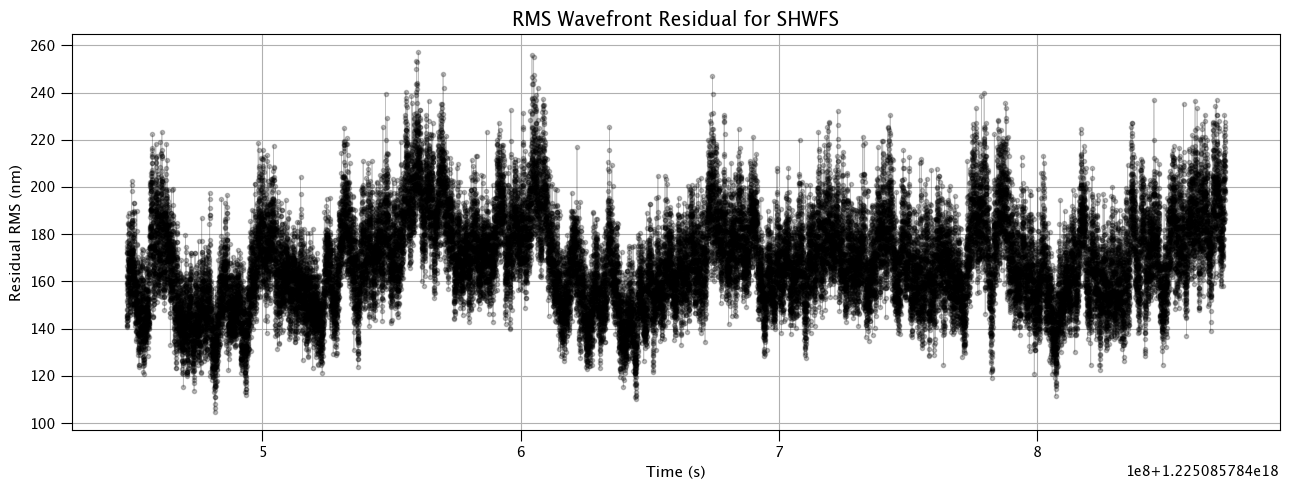

In [231]:
fig, axes = plt.subplots(figsize=(13, 5))
plt.plot(sample1.a.timestamp[0], sample1.a.residualrms[0][0], '.-', linewidth=0.5, alpha=0.25, color="black")
plt.title(f"RMS Wavefront Residual for SHWFS", fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Residual RMS (nm)')
plt.tight_layout()
plt.grid(True)
plt.show()

**Tip-Tilt Validation**

KAON 1165 AO Telemetry 4 PSF-R file states that the four entries for each subarray in the apdcounts data below correspond to the "four quadrants." The telemetry colab notebook states:

For each telemetry files, we get out one number for each entry by averaging over timestamps and(or) averaging over space:
- residual_rms: average over timestamps
- residual_rms_std: average over timestamps
- apd_counts & apd_counts_std: first average over space, then over timestamps

I am assuming the "averaging over space" for the apdcounts data is averaging over the four quadrants referenced in the KAON (WFS divided into four quadrants).

In [232]:
# Apdcounts for TT sensor to validate TT brightness input into MAOS
sample1.b.apdcounts[0]

array([[253., 305., 198., 257.],
       [230., 274., 243., 303.],
       [195., 281., 234., 247.],
       ...,
       [223., 272., 232., 287.],
       [220., 288., 245., 284.],
       [205., 274., 228., 294.]], dtype=float32)

In [233]:
# Average apdcounts over space and then over time
space_avg = np.mean(sample1.b.apdcounts[0], axis=1)
np.mean(space_avg)

247.75195

Unit for this data is simply "counts." powfs.siglev for c0103 is [1270 1621 3723], where the second entry corresponds to the signal level (e.g. brightness) for STRAP, the TT WFS. 

In [234]:
sample1.header[-3]

b"STAPDQMN= '62635.500         ' / STRAP Quad Mean APD counts (co                 "

In [235]:
# According to KAON 1165 AO Telemetry, DTTCENTROIDS is a measure of the TT 
# residual in arcsec
ttcentroids_x = sample1.b.dttcentroids[0][:,0]
ttcentroids_y = sample1.b.dttcentroids[0][:,1]

RESIDUALWAVEFRONT

[0:348, *]   : residuals at the 349 actuators | Volts (volts-2-micron conversion factor is 0.6 microns/volt)

[349:350, *] : residual tip/tilt              | arcsec

[351, *]     : residual defocus               | microns



In [137]:
# According to KAON 1165, RESIDUALWAVEFRONT is the residual wavefront in various units (see above),
# but shape of data.a.residualwavefront[0] is (42516, 352), so flipped from expectation of
# document

# measurement source is from laser, not from NGS on TT sensor, hence why it lives in data.a
tt_residual = sample1.a.residualwavefront[0][:, 349:350] 

[autoreload of paarti.utils.maos_utils failed: Traceback (most recent call last):
  File "/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/opt/mambaforge3/envs/astro/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/u/bdigia/code/python/paarti/paarti/utils/maos_utils.py", line 3773
    d

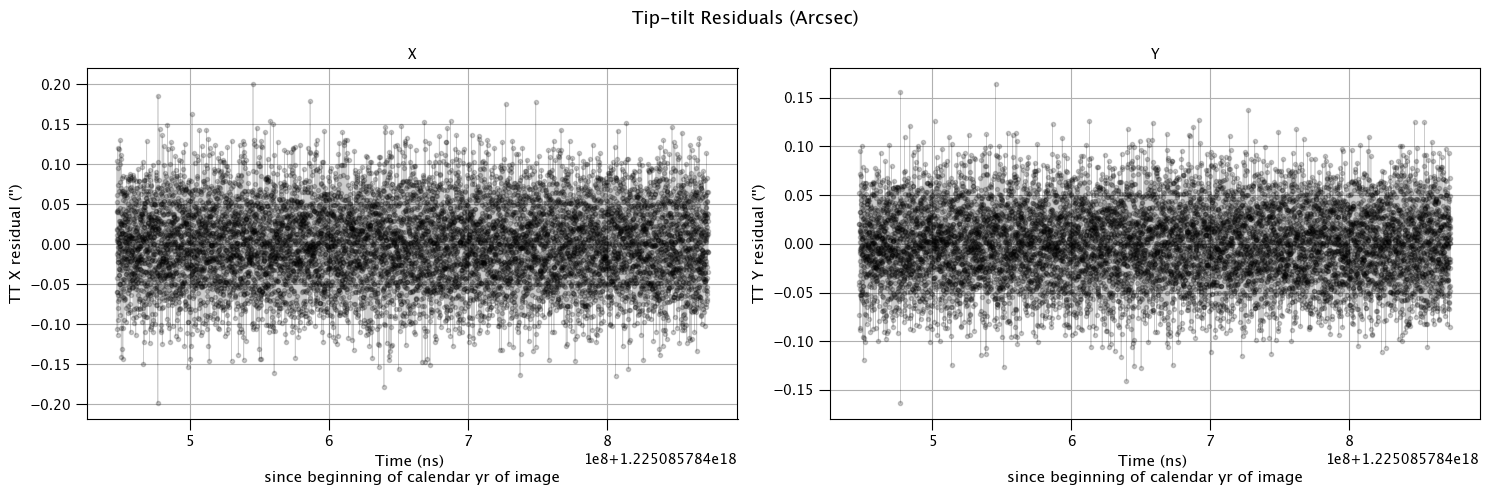

In [237]:
# Plot tip tilt centroid offsets
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].grid(True)
axes[1].grid(True)
axes[0].plot(sample1.b.timestamp[0], ttcentroids_x, 'k.-', linewidth=0.5, alpha=0.2)
axes[1].plot(sample1.b.timestamp[0], ttcentroids_y, 'k.-', linewidth=0.5, alpha=0.2)
axes[0].set_xlabel(f"Time (ns) \nsince beginning of calendar yr of image")
axes[1].set_xlabel(f"Time (ns) \nsince beginning of calendar yr of image")
axes[0].set_ylabel("TT X residual ('')")
axes[1].set_ylabel("TT Y residual ('')")
axes[0].set_title("X")
axes[1].set_title("Y")
fig.suptitle("Tip-tilt Residuals (Arcsec)")
plt.tight_layout()

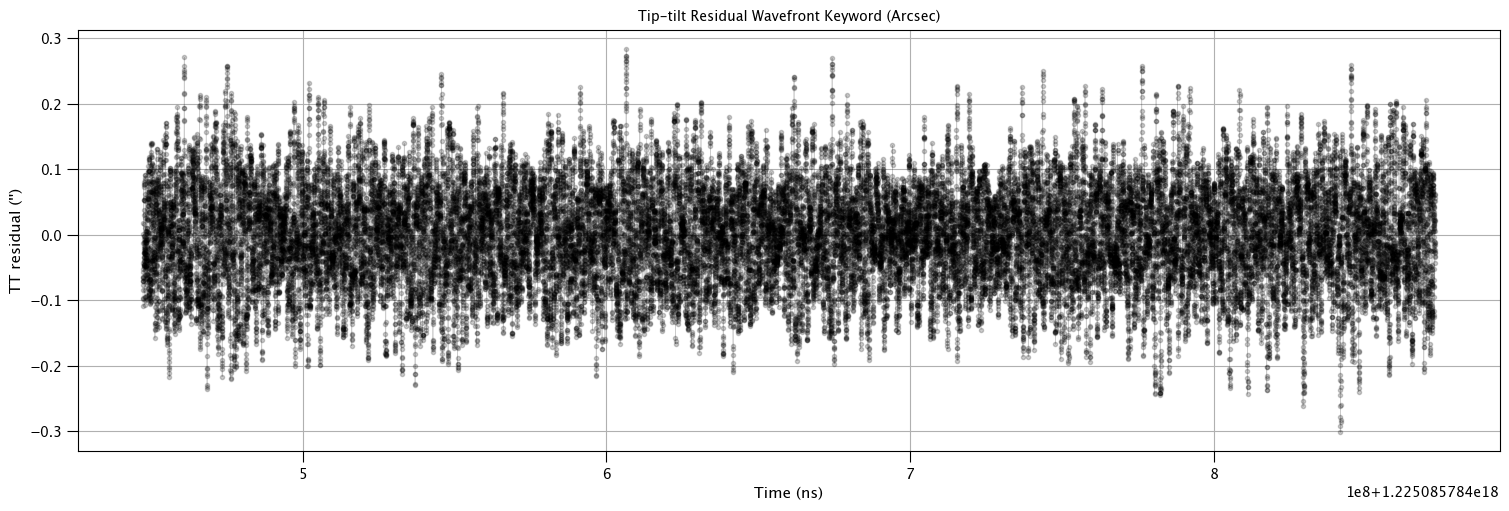

In [238]:
fig, axes = plt.subplots(figsize=(15, 5))
plt.plot(sample1.a.timestamp[0], tt_residual, 'k.-', alpha=0.2, linewidth=0.5)
plt.tight_layout()
plt.xlabel("Time (ns)")
plt.ylabel("TT residual ('')")
plt.title("Tip-tilt Residual Wavefront Keyword (Arcsec)")
plt.grid(True)

**X Tip-Tilt Power Spectrum**

In [257]:
# Fourier transform TT centroids x
n = len(ttcentroids_x)
# ttcentroids_fftx = fft(ttcentroids_x)
# Real Fourier transform TT centroids (x) into frequency space
ttcentroids_fftx = np.fft.rfft(ttcentroids_x)
# Grab real (non-negative) frequencies
freq = np.fft.rfftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)

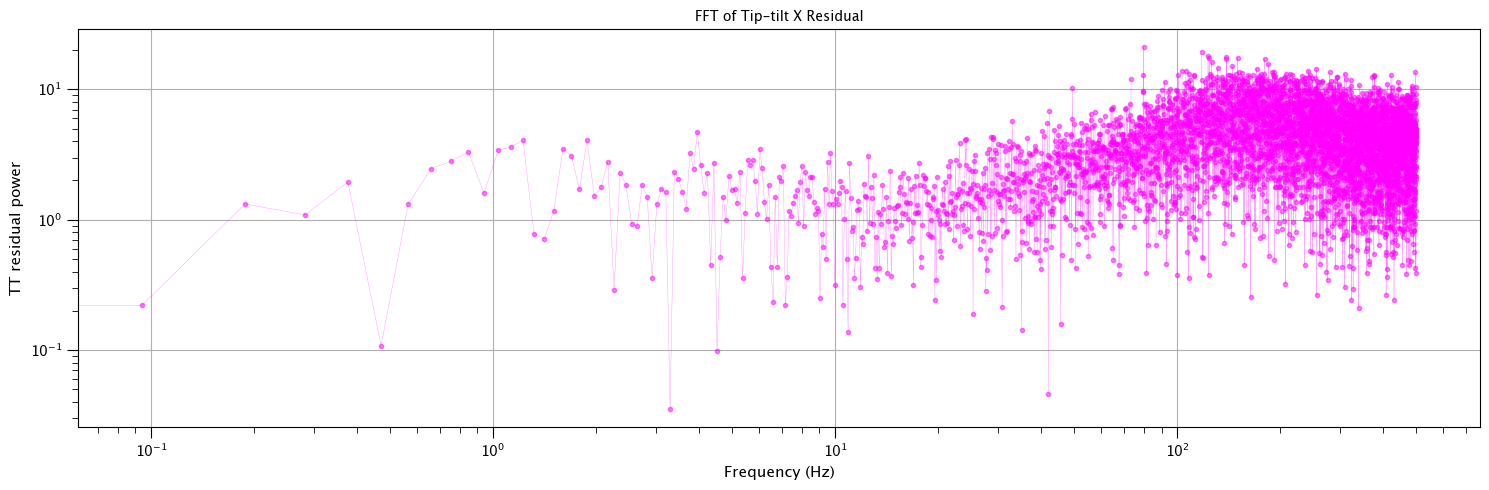

In [258]:
plt.figure(figsize=(15, 5))
plt.loglog(freq, np.abs(ttcentroids_fftx), '.-', linewidth=0.25, color="magenta", alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt X Residual")
plt.grid(True)
plt.tight_layout()

**Y Tip-Tilt Power Spectrum**

In [241]:
# Fourier transform TT centroids y
n = len(ttcentroids_y)
# Real Fourier transform TT centroids (y) into frequency space
ttcentroids_ffty = np.fft.rfft(ttcentroids_y)
# Grab real (non-negative) frequencies
freq = np.fft.rfftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)
pos_freq = freq

print(ttcentroids_y.shape)
print(ttcentroids_ffty.shape)
print(freq.shape)

(10629,)
(5315,)
(5315,)


(0.0, 75.0)

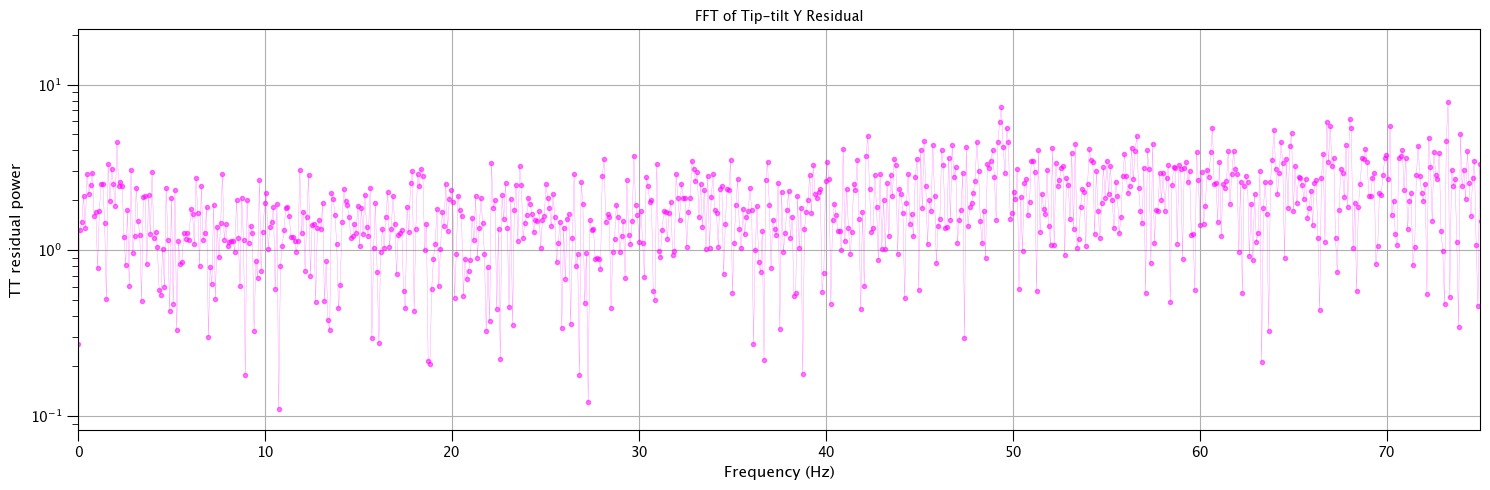

In [265]:
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Y Residual")
plt.grid(True)
plt.tight_layout()
plt.xlim(0.0, 75.0)

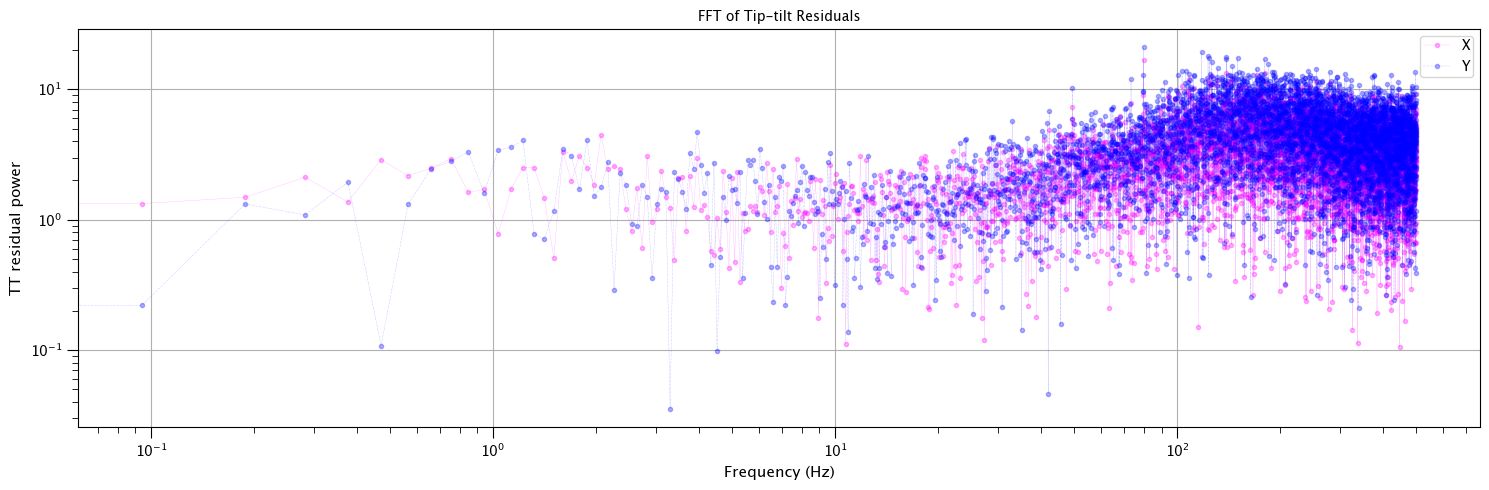

In [243]:
plt.figure(figsize=(15, 5))
plt.loglog(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.loglog(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()

**Fourier Transform of TT residual data from 'RESIDUALWAVEFRONT' keyword**

as opposed to RESIDUALRMS keyword

In [244]:
# Fourier transform TT centroids y
n = len(tt_residual)
# Real Fourier transform TT centroids (y) into frequency space
tt_residual_fft = np.fft.rfft(tt_residual)
print(tt_residual_fft.shape)
tt_residual_fft.shape
# Grab real (non-negative) frequencies
freq = np.fft.fftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)

(42516, 1)


In [245]:
print(tt_residual.shape)
print(tt_residual_fft.shape)
print(freq.shape)

(42516, 1)
(42516, 1)
(42516,)


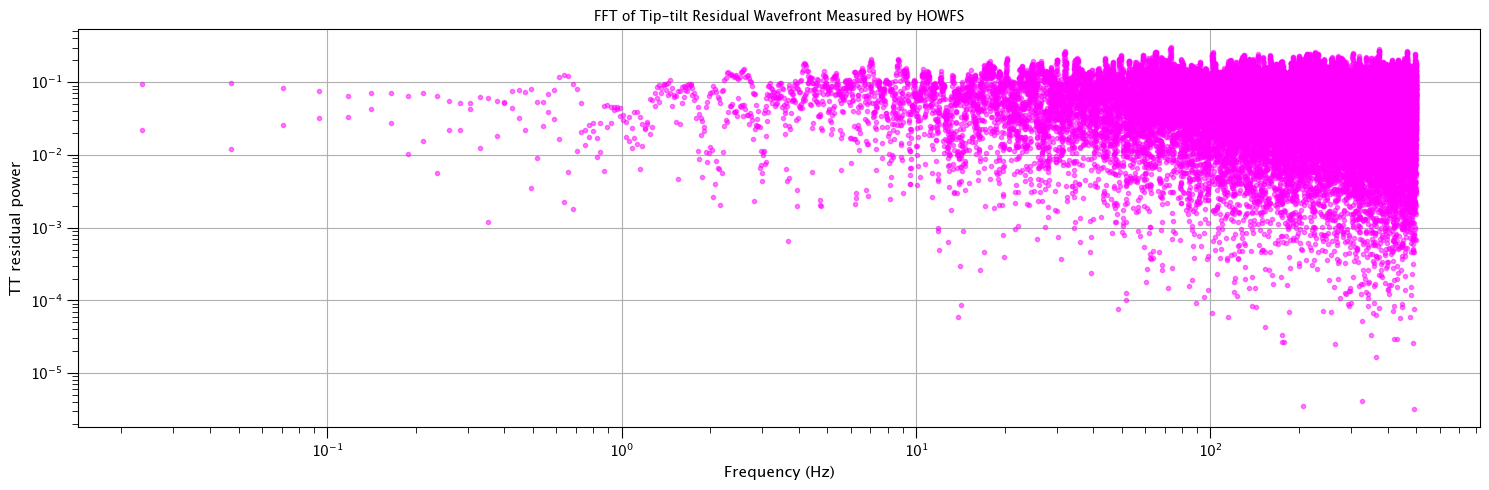

In [246]:
plt.figure(figsize=(15, 5))
plt.loglog(np.abs(freq), np.abs(tt_residual_fft), '.', linewidth=0.25, color="magenta", alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residual Wavefront Measured by HOWFS")
plt.grid(True)
plt.tight_layout()

**Log-Linear Versions of Plots**

ValueError: x and y must have same first dimension, but have shapes (21259,) and (5315,)

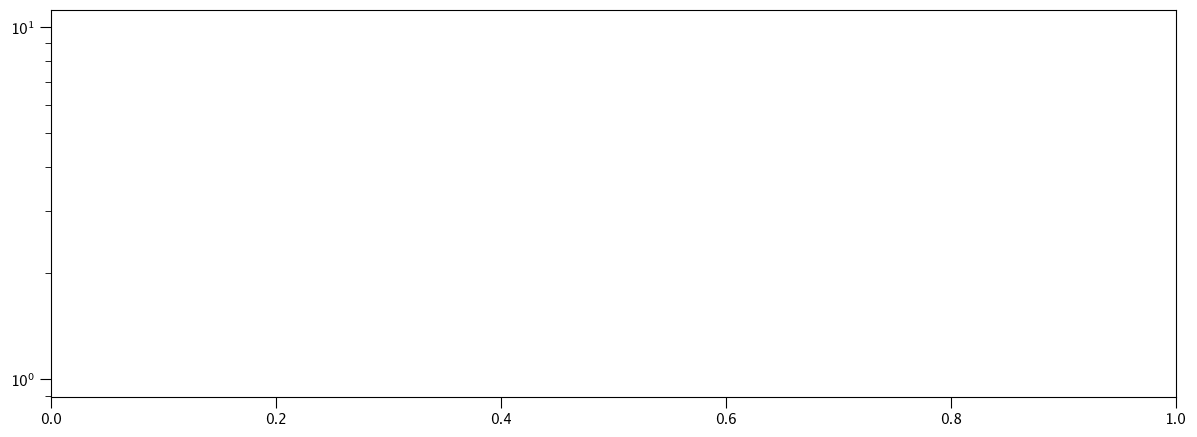

In [247]:
freq = np.fft.rfftfreq(n, d=0.001) # d = 1/sample_rate = 1.0/1000.0 Hz = 1 ms (average timestamp spacing above)
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()

Zoom in on lower frequencies

ValueError: x and y must have same first dimension, but have shapes (21259,) and (5315,)

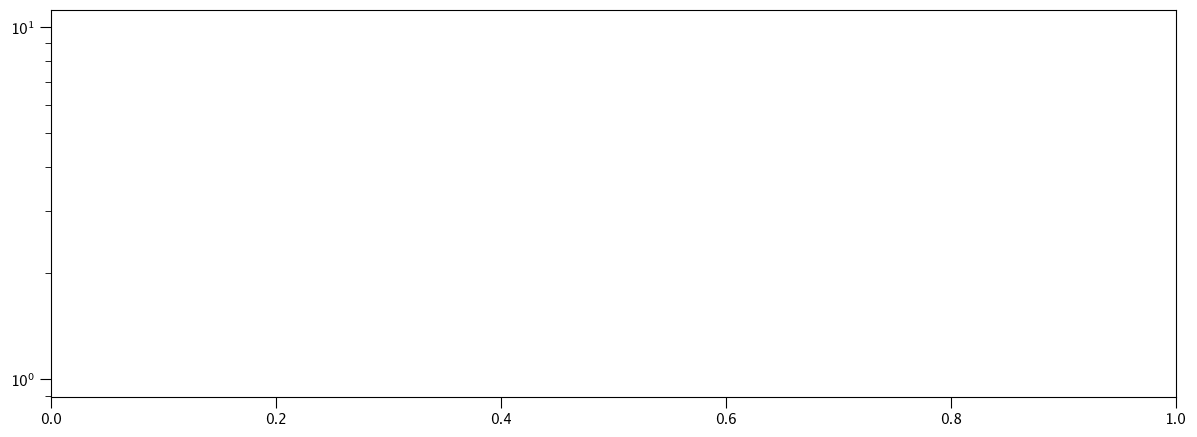

In [248]:
freq = np.fft.rfftfreq(n, d=0.001)
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(0, 100.0)

**Average Power Spectra**

ValueError: x and y must have same first dimension, but have shapes (21259,) and (5315,)

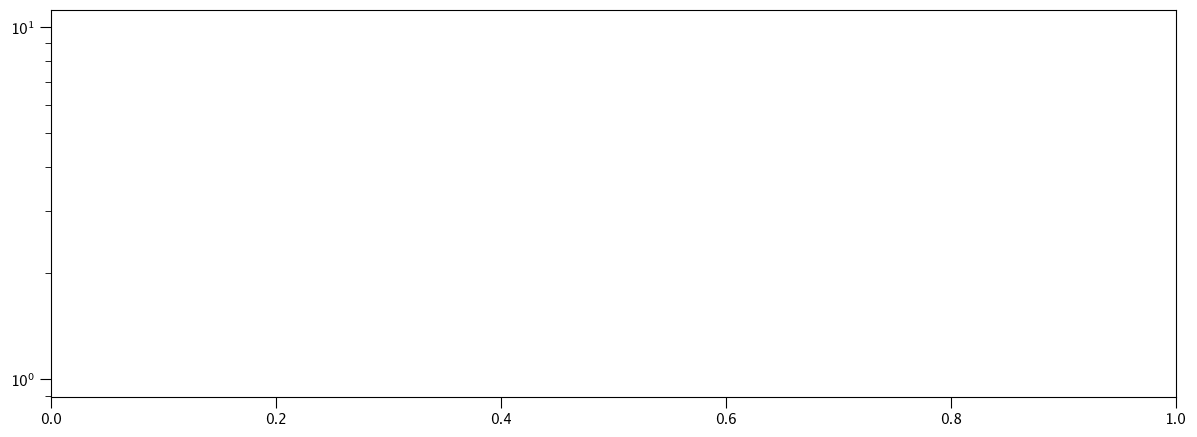

In [249]:
ttcentroids_fft = np.mean( [np.abs(ttcentroids_fftx), np.abs(ttcentroids_ffty)], axis=0)
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.-', linewidth=0.25, color="magenta", alpha=0.3, label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-.', linewidth=0.25, color="blue", alpha=0.3, label="Y")
plt.semilogy(freq, ttcentroids_fft, '.-', linewidth=0.5, color='gold', alpha=0.3, label="Avg")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(0, 100.0)

(0.0, 100.0)

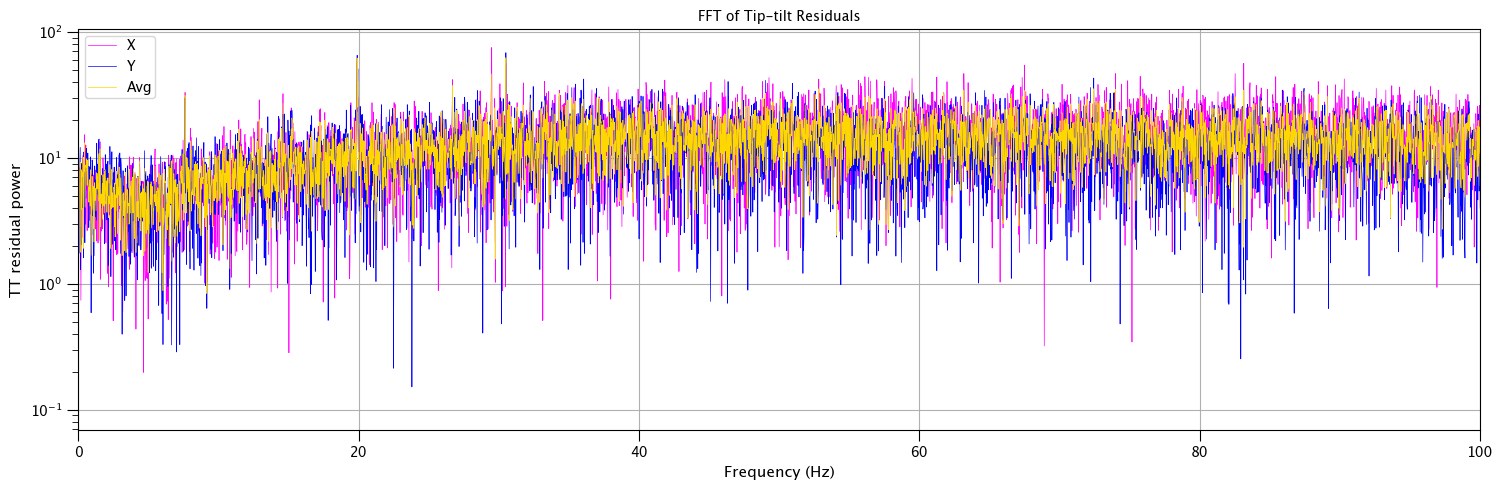

In [201]:
plt.figure(figsize=(15, 5))
plt.semilogy(freq, np.abs(ttcentroids_ffty), linewidth=0.5, color="magenta", label="X")
plt.semilogy(freq, np.abs(ttcentroids_fftx), linewidth=0.5, color="blue", label="Y")
plt.semilogy(freq, ttcentroids_fft, linewidth=0.5, color='gold', label="Avg")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TT residual power")
plt.title("FFT of Tip-tilt Residuals")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(0, 100.0)

**Pseudo Open Loop vs Closed Loop**

DTTCOMMANDS are 'down' tip-tilt actuator commands in absolute offsets (arcseconds)

TTCOMMANDS are laser tip-tilt actuator commands --> TT signal coming from the fast, HOWFS (arcsec)

In [250]:
dtt_commands = sample1.b.dttcommands[0]
tt_commands = sample1.a.ttcommands[0]

In [251]:
dtt_commands_x = dtt_commands[:,0]
dtt_commands_y = dtt_commands[:,1]
tt_commands_x = tt_commands[:,0]
tt_commands_y = tt_commands[:,1]

In [252]:
# Add commands to centroids = offsets to create pseudo open loop (pol)
# measurement (arrays should be aligned and same length despite time
# lag between entering of command and execution by actuator)
dtt_pol_x = np.add(dtt_commands_x, ttcentroids_x)
dtt_pol_y = np.add(dtt_commands_y, ttcentroids_y)
tt_pol_x = np.add(tt_commands_x, ttcentroids_x)
tt_pol_y = np.add(tt_commands_y, ttcentroids_y)
print(dtt_pol_x.shape, dtt_pol_y.shape, tt_pol_x.shape, tt_pol_y.shape)

ValueError: operands could not be broadcast together with shapes (42516,) (10629,) 

ValueError: x and y must have same first dimension, but have shapes (10629,) and (42516,)

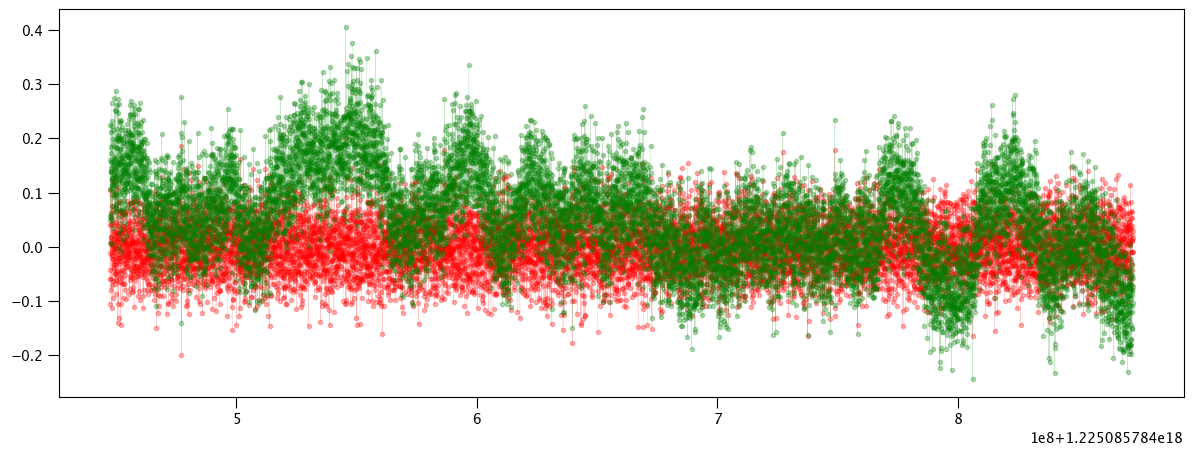

In [253]:
plt.figure(figsize=(15, 5))
plt.plot(sample1.b.timestamp[0], ttcentroids_x, '.-', linewidth=0.25, color="red", alpha=0.3, label="CL TT X")
plt.plot(sample1.b.timestamp[0], dtt_pol_x, '.-', linewidth=0.25, color="green", alpha=0.3, label="Down POL TT X")
plt.plot(sample1.b.timestamp[0], tt_pol_x, '.-', linewidth=0.25, color="violet", alpha=0.3, label="HOWFS POL TT X")
plt.xlabel("Time (s)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) X Measurements (Arcsec)")
plt.grid(True)
plt.tight_layout()
plt.legend()

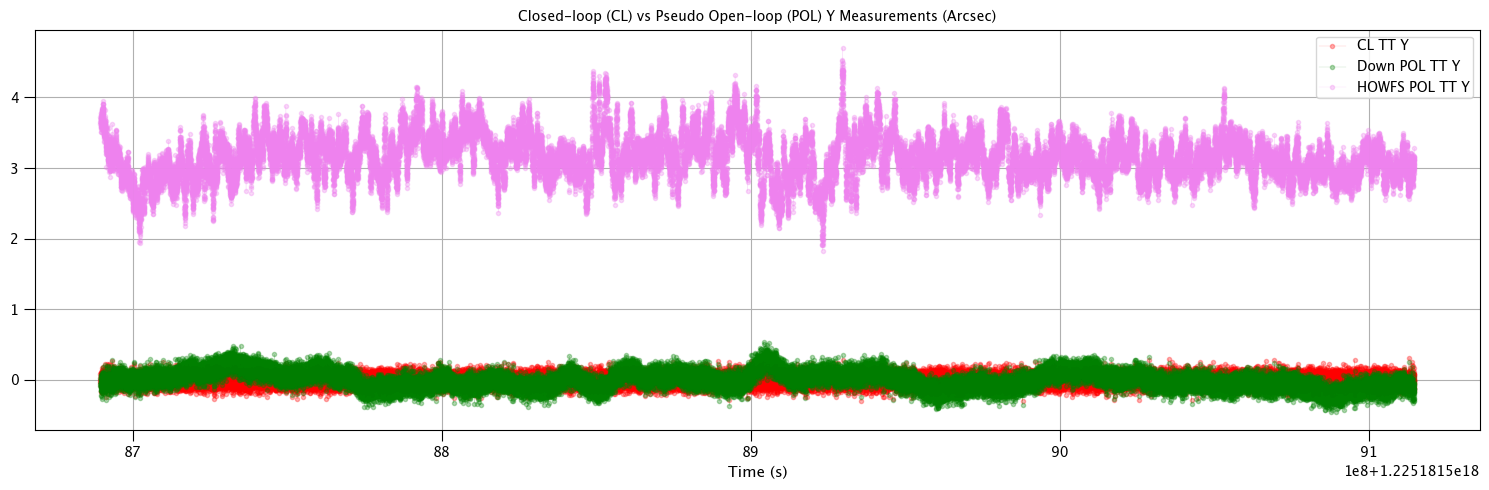

In [66]:
plt.figure(figsize=(15, 5))
plt.plot(sample1.b.timestamp[0], ttcentroids_y, '.-', linewidth=0.25, color="red", alpha=0.3, label="CL TT Y")
plt.plot(sample1.b.timestamp[0], dtt_pol_y, '.-', linewidth=0.25, color="green", alpha=0.3, label="Down POL TT Y")
plt.plot(sample1.b.timestamp[0], tt_pol_y, '.-', linewidth=0.25, color="violet", alpha=0.3, label="HOWFS POL TT Y")
plt.xlabel("Time (s)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Y Measurements (Arcsec)")
plt.grid(True)
plt.tight_layout()
plt.legend()

In [67]:
# Fourier transform pseudo open loop measurement
nx = len(tt_pol_x)
ny = len(tt_pol_y)
dnx = len(dtt_pol_x)
dny = len(dtt_pol_y)

# Real Fourier transform TT centroids (y) into frequency space
dtt_pol_fftx = np.fft.rfft(dtt_pol_x)
dtt_pol_ffty = np.fft.rfft(dtt_pol_y)
tt_pol_fftx = np.fft.rfft(tt_pol_x)
tt_pol_ffty = np.fft.rfft(tt_pol_y)
# Grab real (non-negative) frequencies
freq = np.fft.rfftfreq(nx, d=0.001)

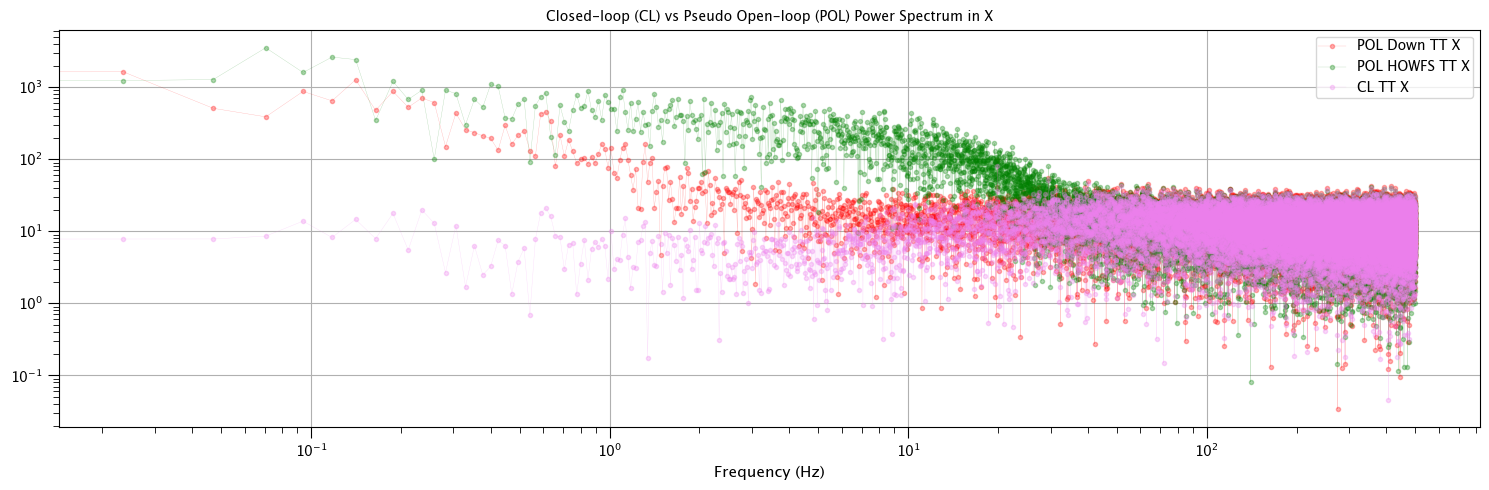

In [68]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.loglog(freq, np.abs(dtt_pol_fftx), '.-', linewidth=0.25, color="red", alpha=0.3, label="POL Down TT X")
plt.loglog(freq, np.abs(tt_pol_fftx), '.-', linewidth=0.25, color="green", alpha=0.3, label="POL HOWFS TT X")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.loglog(freq, np.abs(ttcentroids_fftx), '.-', linewidth=0.25, color="violet", alpha=0.3, label="CL TT X")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in X")
plt.grid(True)
plt.tight_layout()
plt.legend()

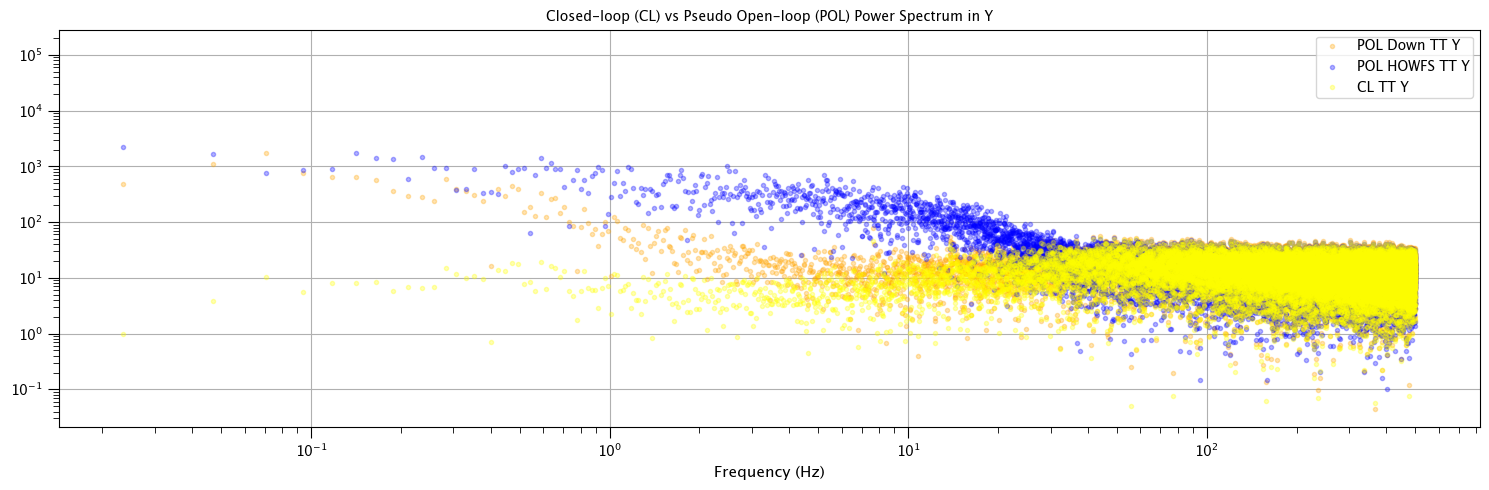

In [69]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.loglog(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.loglog(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.loglog(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()

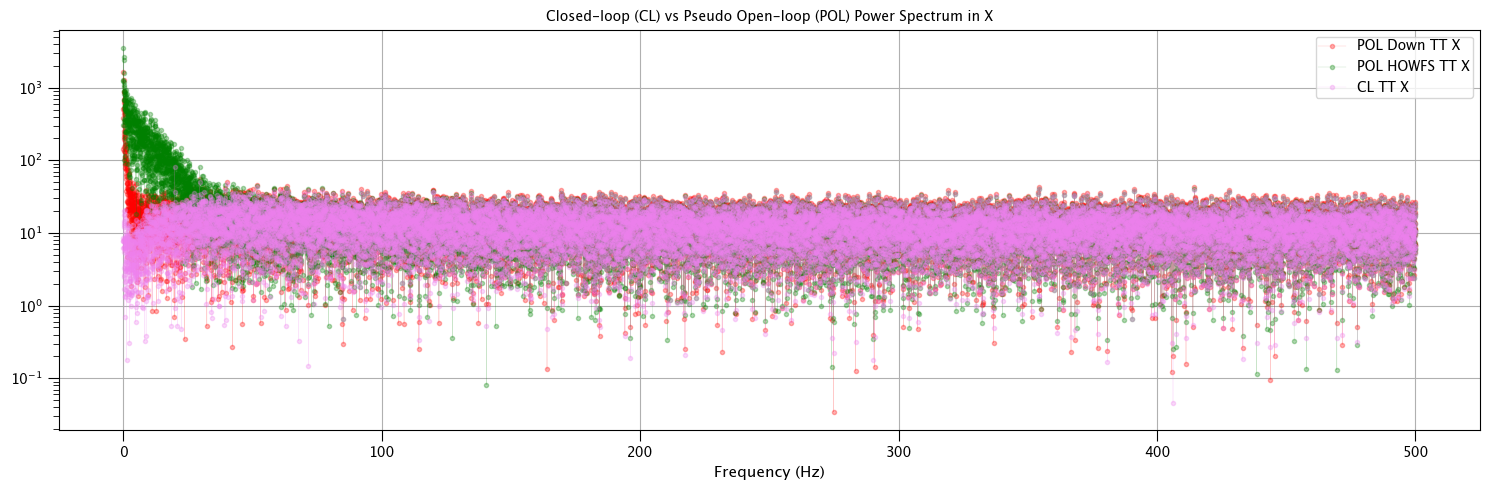

In [70]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_fftx), '.-', linewidth=0.25, color="red", alpha=0.3, label="POL Down TT X")
plt.semilogy(freq, np.abs(tt_pol_fftx), '.-', linewidth=0.25, color="green", alpha=0.3, label="POL HOWFS TT X")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_fftx), '.-', linewidth=0.25, color="violet", alpha=0.3, label="CL TT X")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in X")
plt.grid(True)
plt.tight_layout()
plt.legend()

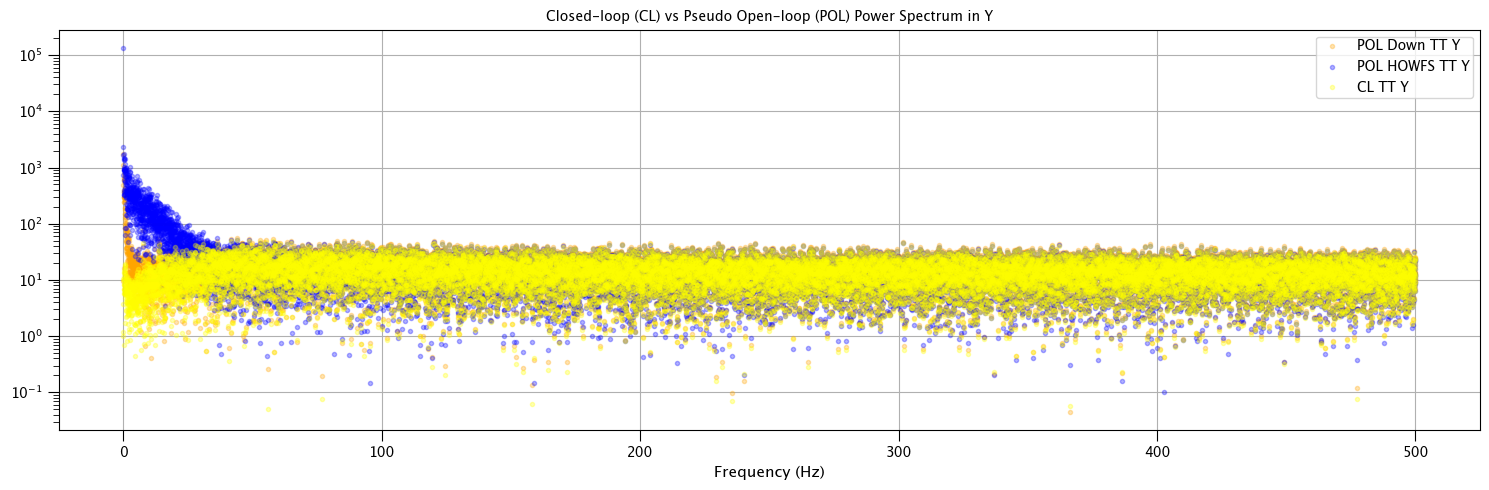

In [71]:
plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.semilogy(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()

Where does break in power spectra occur?

Elbow using pseudo-open-loop curve: 59.201241885407846 Hz
Knee using closed-loop curve: 53.41518487157776 Hz


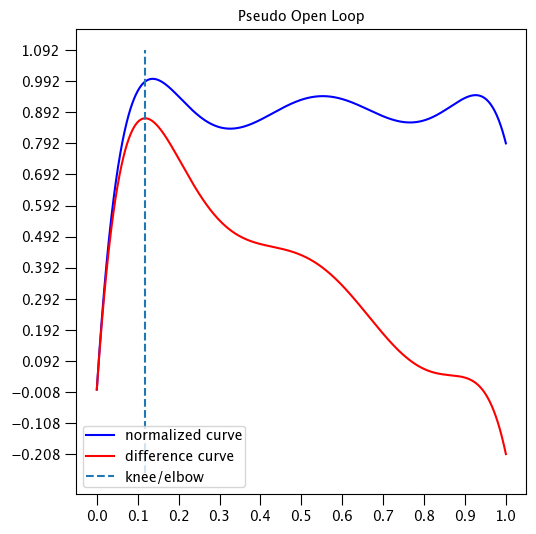

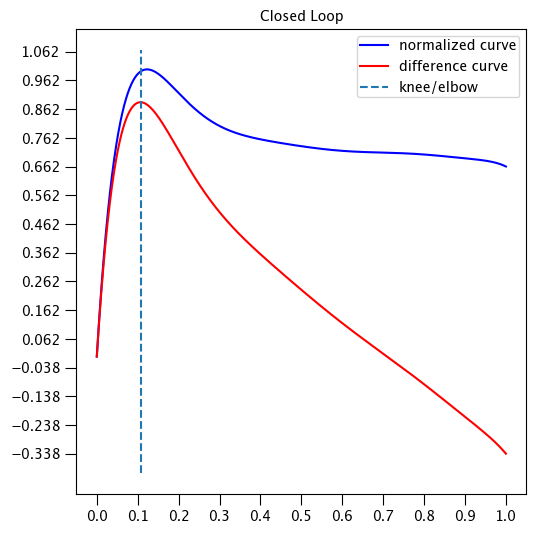

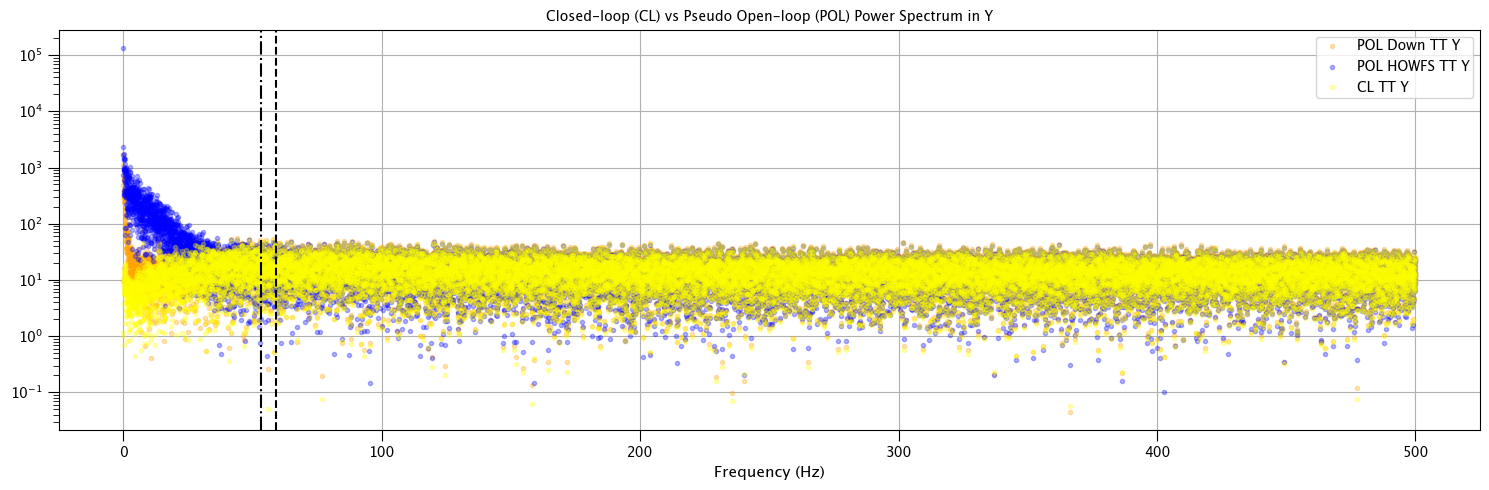

In [126]:
# indices = np.argsort(freq)[:100]
# S = Sensitivity = 1.0 as suggested by kneed docs, concave curve to locate knee point, increasing direction for positive slope
kneedle_pol = kneed.KneeLocator(freq, np.abs(tt_pol_ffty), S=1.0, curve='convex', 
                            direction='decreasing', interp_method='polynomial', 
                            polynomial_degree=6)
kneedle_cl = kneed.KneeLocator(freq, np.abs(ttcentroids_ffty), S=1.0, curve='concave', 
                            direction='increasing', interp_method='polynomial', 
                            polynomial_degree=8)
elbow = kneedle_pol.elbow # the returned knee point is the value on the x-axis (frequency)
print(f'Elbow using pseudo-open-loop curve: {elbow} Hz')
knee = kneedle_cl.knee
print(f'Knee using closed-loop curve: {knee} Hz')
kneedle_pol.plot_knee_normalized(title='Pseudo Open Loop')
kneedle_cl.plot_knee_normalized(title='Closed Loop')

plt.figure(figsize=(15, 5))
# Pseudo-open loop, calculated above
plt.semilogy(freq, np.abs(dtt_pol_ffty), '.', linewidth=0.25, color="orange", alpha=0.3, label="POL Down TT Y")
plt.semilogy(freq, np.abs(tt_pol_ffty), '.', linewidth=0.25, color="blue", alpha=0.3, label="POL HOWFS TT Y")
# Closed-loop, calculated earlier (centroids = offsets data --> closed-loop)
plt.semilogy(freq, np.abs(ttcentroids_ffty), '.', linewidth=0.25, color="yellow", alpha=0.3, label="CL TT Y")
plt.axvline(x=elbow, linestyle='--', color='black')
plt.axvline(x=knee, linestyle='-.', color='black')
plt.xlabel("Frequency (Hz)")
plt.title("Closed-loop (CL) vs Pseudo Open-loop (POL) Power Spectrum in Y")
plt.grid(True)
plt.tight_layout()
plt.legend()